# 📊 Full Dataset Correlation Analysis — CIC-IDS-2018

**Purpose:** Complete, reproducible correlation analysis on the full 16M-row dataset.  
Identifies redundant features and produces a final drop list ready to inject into your training pipeline.

| # | Section | What happens |
|---|---------|-------------|
| 1 | Imports & Config | Paths, thresholds, feature groups |
| 2 | Load Full Dataset | Chunked CSV reader |
| 3 | Data Cleaning | Remove corrupt rows |
| 4 | Descriptive Statistics | Stats for all features |
| 5 | Variance Analysis | Drop zero-variance |
| 6 | Skewness Analysis | Confirm transformer choices |
| 7 | Feature–Label Correlation | Full dataset predictiveness |
| 8 | Feature–Feature Correlation | Full dataset matrix |
| 9 | High-Corr Pairs | Find redundant clusters |
| 10 | Greedy Drop Decision | Keep most predictive per pair |
| 11 | Apply Drop | Update X_full + scaling configs |
| 12 | Pairplot | Visual cluster check |
| 13 | Post-Drop Check | Confirm no redundancy remains |
| 14 | Final Report | Summary + all output files |


## 1. Imports & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 130
sns.set_style('whitegrid')

# ─── CONFIG ───────────────────────────────────────────────────────────
INPUT_FILE      = 'archive/shared_sample_200k.csv'
OUTPUT_DIR      = 'correlation_analysis/'
CHUNK_SIZE      = 100_000
CORR_THRESHOLD  = 0.95        # |r| >= this → redundant pair
USE_FULL_DATA   = True        # True = full 16M rows | False = stratified sample
SAMPLE_N        = 500_000     # only used when USE_FULL_DATA = False
RANDOM_STATE    = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── FEATURE GROUPS ───────────────────────────────────────────────────
NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]
POWER_TRANSFORMER_FEATURES = [
    'Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
    'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
    'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
    'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
    'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
    'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
    'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Len',
    'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Max',
    'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'Down/Up Ratio',
    'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
    'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Idle Mean', 'Idle Max', 'Idle Min'
]
STANDARD_SCALER_FEATURES = ['Fwd Seg Size Min']
NO_SCALING_FEATURES = [
    'Protocol', 'RST Flag Cnt', 'PSH Flag Cnt',
    'ACK Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt'
]

corr_mode = 'FULL DATASET' if USE_FULL_DATA else f'{int(SAMPLE_N):,}-row stratified sample'
print('=' * 70)
print('📊 FULL DATASET CORRELATION ANALYSIS — CIC-IDS-2018')
print('=' * 70)
print(f'   Input       : {INPUT_FILE}')
print(f'   Output dir  : {OUTPUT_DIR}')
print(f'   Threshold   : |r| >= {CORR_THRESHOLD}')
print(f'   Corr mode   : {corr_mode}')


📊 FULL DATASET CORRELATION ANALYSIS — CIC-IDS-2018
   Input       : archive/full_df_binary_labels.csv
   Output dir  : correlation_analysis/
   Threshold   : |r| >= 0.95
   Corr mode   : FULL DATASET


## 2. Load Full Dataset (chunked, memory-safe)

In [2]:
t0 = time.time()
print(f'Chunked reading: {INPUT_FILE}  (chunk={CHUNK_SIZE:,})')
chunks, total = [], 0
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    chunks.append(chunk)
    total += len(chunk)
    if (i + 1) % 20 == 0:
        print(f'  Chunk {i+1:>4} | Rows: {total:>12,}')

df_full = pd.concat(chunks, ignore_index=True)
del chunks
df_full = df_full.drop(columns=['Label'], errors='ignore')

print(f'\n✅ Loaded in {time.time()-t0:.1f}s')
print(f'   Shape  : {df_full.shape}')
print(f'   Memory : {df_full.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'\nClass distribution:')
vc = df_full['Label_Binary'].value_counts()
for k, v in vc.items():
    label = 'Benign' if k == 0 else 'Attack'
    print(f'   {label} ({k}): {v:>10,}  ({v/len(df_full)*100:.1f}%)')


Chunked reading: archive/full_df_binary_labels.csv  (chunk=100,000)
  Chunk   20 | Rows:    2,000,000
  Chunk   40 | Rows:    4,000,000
  Chunk   60 | Rows:    6,000,000
  Chunk   80 | Rows:    8,000,000
  Chunk  100 | Rows:   10,000,000
  Chunk  120 | Rows:   12,000,000
  Chunk  140 | Rows:   14,000,000
  Chunk  160 | Rows:   16,000,000

✅ Loaded in 61.1s
   Shape  : (16232943, 58)
   Memory : 7.53 GB

Class distribution:
   Benign (0): 13,484,708  (83.1%)
   Attack (1):  2,748,235  (16.9%)


## 3. Data Cleaning — Remove Corrupt Rows

In [3]:
print('Removing corrupt rows (impossible negatives from CICFlowMeter bug)...')
before = len(df_full)
cols_check = [c for c in NON_NEGATIVE_FEATURES if c in df_full.columns]

for col in cols_check:
    n = (df_full[col] < 0).sum()
    if n > 0:
        print(f'  ⚠️  {col:<35} {n:>8,} corrupt values')

corrupt_mask = (df_full[cols_check] < 0).any(axis=1)
df_full = df_full[~corrupt_mask].copy()

X_full = df_full.drop(['Label_Binary'], axis=1).select_dtypes(include=[np.number])
y_full = df_full['Label_Binary'].copy()
del df_full

print(f'\n   Before : {before:>12,}')
print(f'   Removed: {before - len(y_full):>12,} corrupt rows')
print(f'   After  : {len(y_full):>12,}')
print(f'\n✅ X_full: {X_full.shape}  |  y_full: {y_full.shape}')


Removing corrupt rows (impossible negatives from CICFlowMeter bug)...
  ⚠️  Flow Duration                             14 corrupt values
  ⚠️  Flow IAT Mean                             14 corrupt values
  ⚠️  Flow IAT Max                               3 corrupt values
  ⚠️  Flow IAT Min                              15 corrupt values
  ⚠️  Fwd IAT Tot                               14 corrupt values
  ⚠️  Fwd IAT Mean                              14 corrupt values
  ⚠️  Fwd IAT Max                                3 corrupt values
  ⚠️  Fwd IAT Min                               15 corrupt values
  ⚠️  Flow Pkts/s                               14 corrupt values

   Before :   16,232,943
   Removed:           15 corrupt rows
   After  :   16,232,928

✅ X_full: (16232928, 57)  |  y_full: (16232928,)


## 4. Descriptive Statistics — All Features

Computing descriptive statistics on full dataset...
Done in 43.8s

                           mean           std     min      1%        50%            99%             max  skewness  null_pct  zero_pct
Dst Port              9164.0814    18922.2492  0.0000  0.0000    80.0000     61289.0000      65535.0000    1.8636    0.0000    1.4700
Protocol                 8.7541        4.9201  0.0000  0.0000     6.0000        17.0000         17.0000    1.0061    0.0000    1.4700
Flow Duration     12189324.5902 30886445.0972  0.0000  1.0000 20970.0000 118109101.4600  120000000.0000    2.6426    0.0000    0.5900
Tot Fwd Pkts            23.5331     1521.1375  1.0000  1.0000     2.0000        30.0000     309629.0000   88.5563    0.0000    0.0000
Tot Bwd Pkts             6.3127      164.0257  0.0000  0.0000     1.0000        35.0000     123118.0000  170.8038    0.0000   25.4900
TotLen Fwd Pkts        973.0381    62169.0873  0.0000  0.0000    43.0000      2294.0000  144391846.0000  836.6848    0.0000   31.

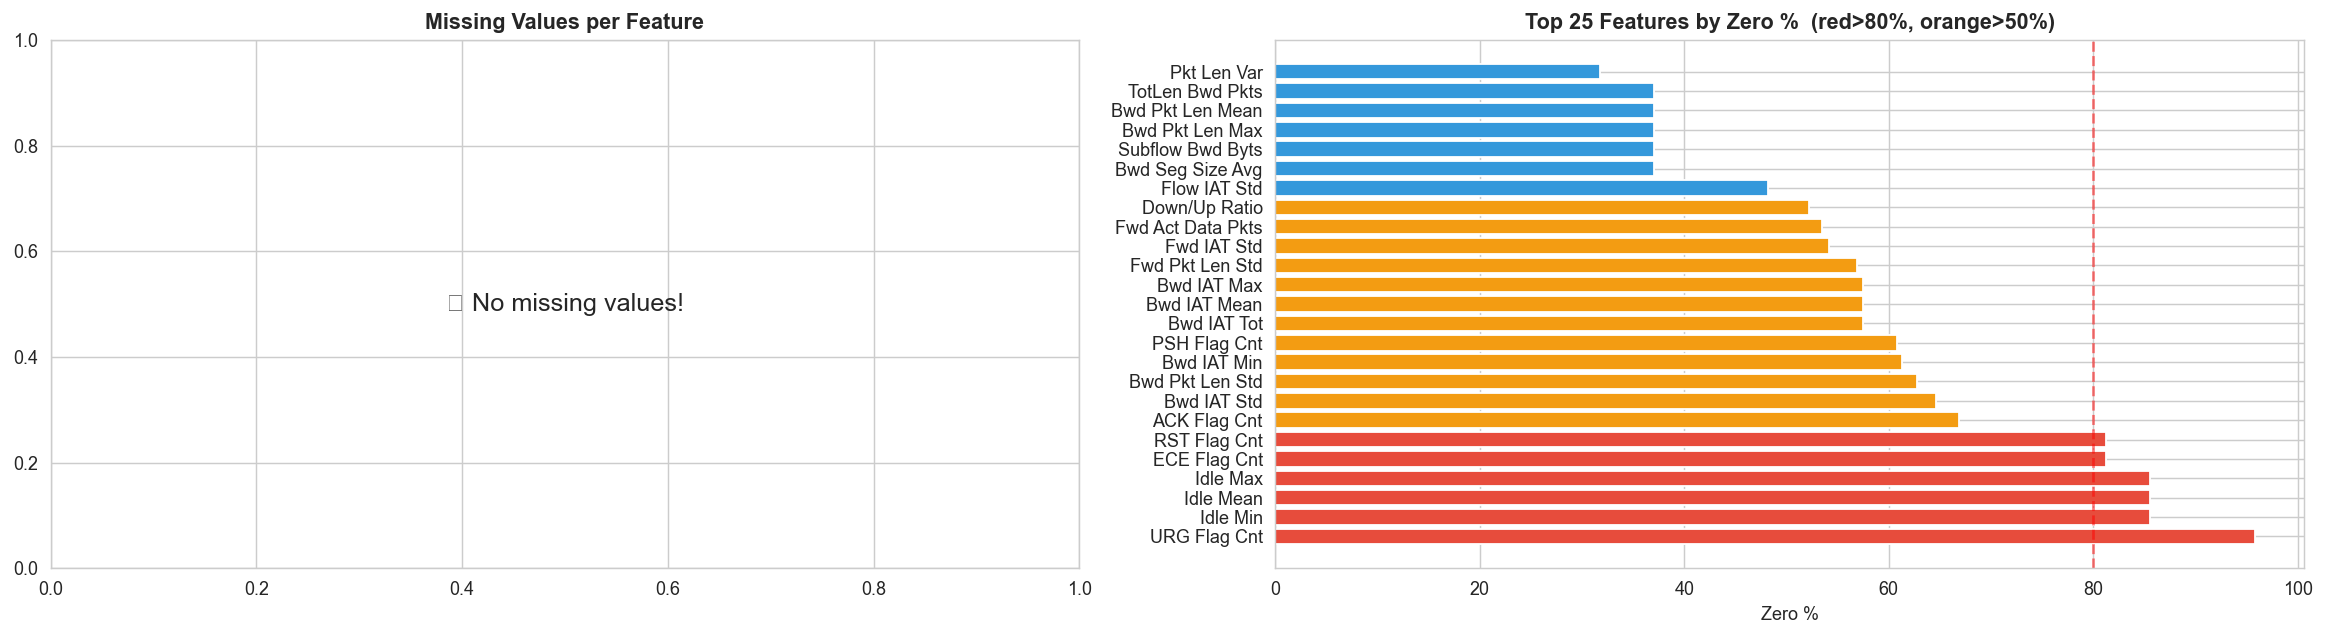

✅ Saved → correlation_analysis/01_missing_zero_analysis.png


In [4]:
print('Computing descriptive statistics on full dataset...')
t0 = time.time()
desc = X_full.describe(percentiles=[.01, .25, .50, .75, .99]).T
desc['skewness'] = X_full.skew()
desc['kurtosis'] = X_full.kurtosis()
desc['null_pct'] = (X_full.isnull().sum() / len(X_full) * 100).round(4)
desc['zero_pct'] = ((X_full == 0).sum() / len(X_full) * 100).round(2)
print(f'Done in {time.time()-t0:.1f}s')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)

cols_show = ['mean', 'std', 'min', '1%', '50%', '99%', 'max', 'skewness', 'null_pct', 'zero_pct']
print('\n' + desc[cols_show].to_string())

desc.to_csv(f'{OUTPUT_DIR}descriptive_statistics.csv')
print(f'\n✅ Saved → {OUTPUT_DIR}descriptive_statistics.csv')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

null_s = desc['null_pct'].sort_values(ascending=False)
null_s = null_s[null_s > 0]
if len(null_s):
    axes[0].barh(null_s.index, null_s.values, color='#e74c3c')
    axes[0].set_xlabel('Null %')
else:
    axes[0].text(0.5, 0.5, '✅ No missing values!', ha='center', va='center',
                 fontsize=14, transform=axes[0].transAxes)
axes[0].set_title('Missing Values per Feature', fontweight='bold')

zero_s = desc['zero_pct'].sort_values(ascending=False).head(25)
colors_z = ['#e74c3c' if v > 80 else '#f39c12' if v > 50 else '#3498db' for v in zero_s.values]
axes[1].barh(zero_s.index, zero_s.values, color=colors_z)
axes[1].set_xlabel('Zero %')
axes[1].set_title('Top 25 Features by Zero %  (red>80%, orange>50%)', fontweight='bold')
axes[1].axvline(80, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}01_missing_zero_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}01_missing_zero_analysis.png')


## 5. Variance Analysis — Drop Zero-Variance Features

Zero-variance features (0):
   None found — all features have variance.

✅ After variance drop: 57 features  (removed 0)


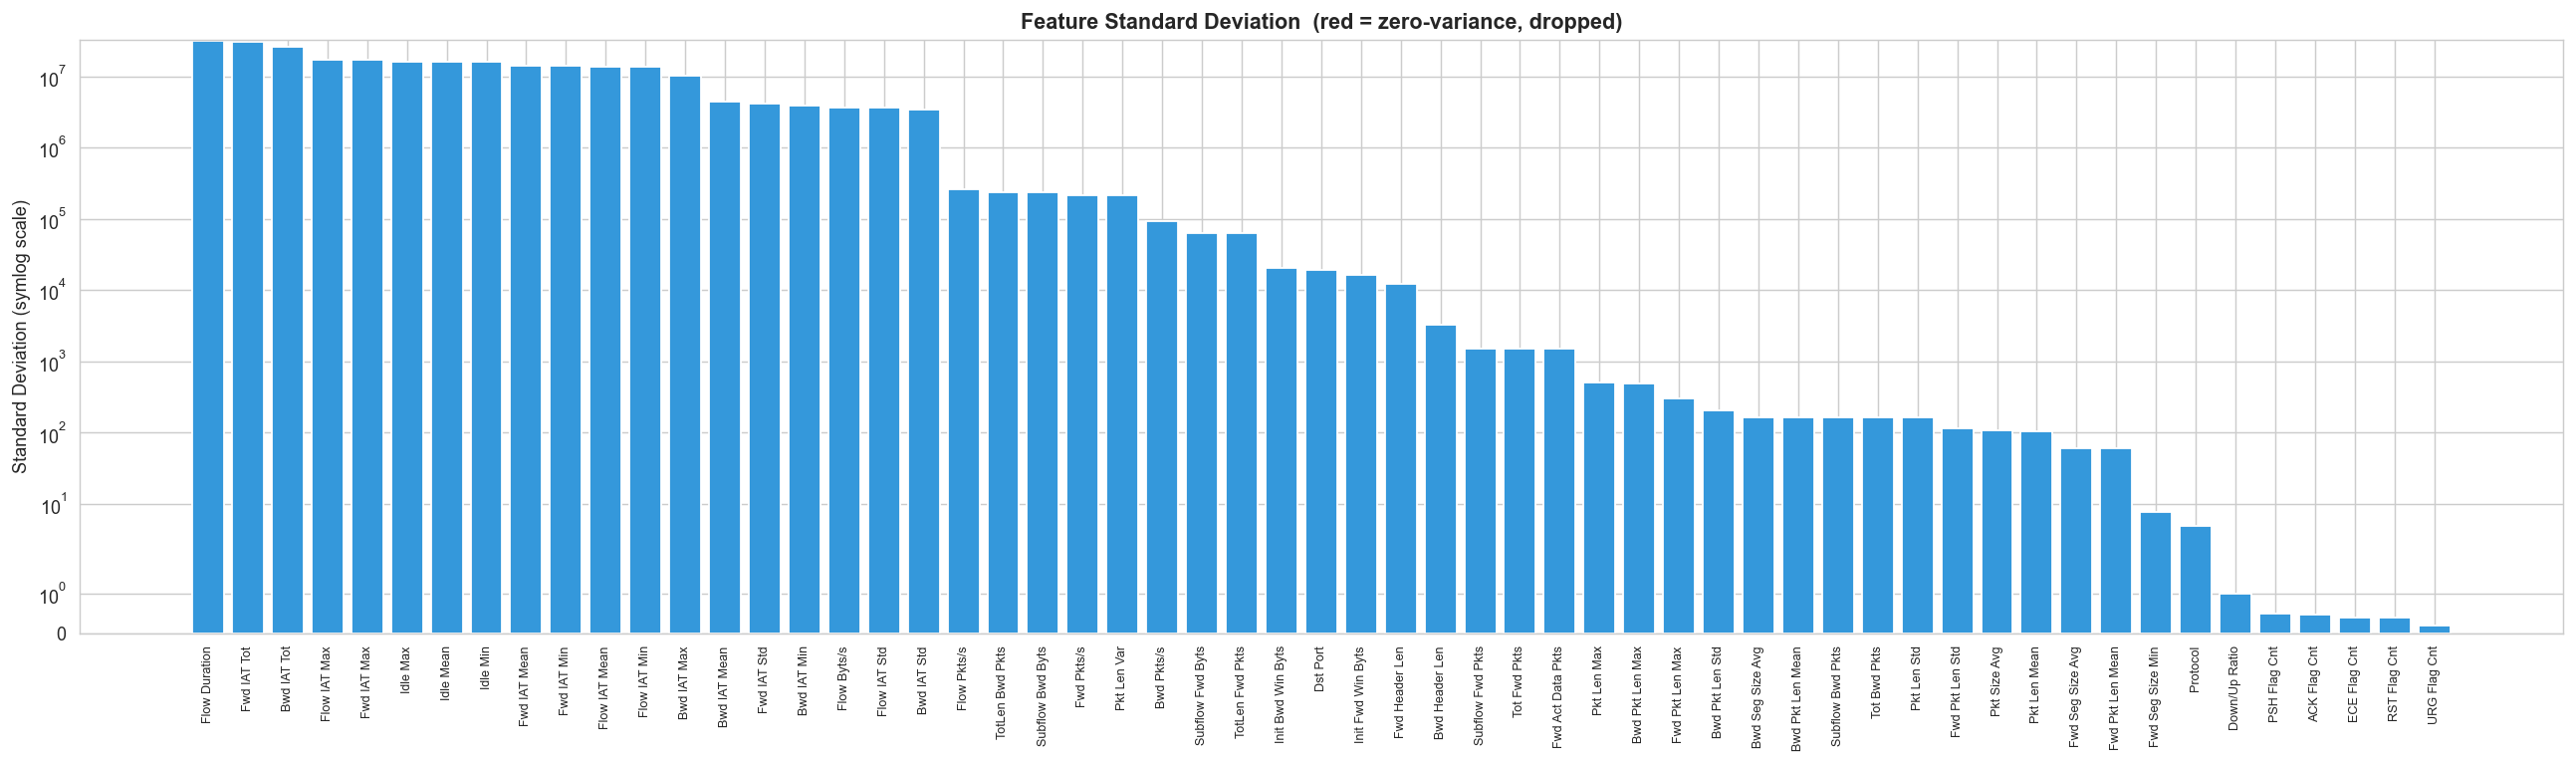

✅ Saved → correlation_analysis/02_variance_analysis.png


In [5]:
std_series  = X_full.std()
mean_series = X_full.mean().abs()

zero_var_cols = std_series[std_series < 1e-10].index.tolist()
print(f'Zero-variance features ({len(zero_var_cols)}):')
for c in zero_var_cols:
    print(f'   - {c}')
if not zero_var_cols:
    print('   None found — all features have variance.')

VARIANCE_DROP = zero_var_cols.copy()
X_full_v = X_full.drop(columns=VARIANCE_DROP) if VARIANCE_DROP else X_full.copy()
print(f'\n✅ After variance drop: {X_full_v.shape[1]} features  (removed {len(VARIANCE_DROP)})')

fig, ax = plt.subplots(figsize=(20, 6))
std_plot = std_series.sort_values(ascending=False)
colors_s = ['#e74c3c' if c in VARIANCE_DROP else '#3498db' for c in std_plot.index]
ax.bar(range(len(std_plot)), std_plot.values, color=colors_s)
ax.set_xticks(range(len(std_plot)))
ax.set_xticklabels(std_plot.index, rotation=90, fontsize=7)
ax.set_ylabel('Standard Deviation (symlog scale)')
ax.set_yscale('symlog')
ax.set_title('Feature Standard Deviation  (red = zero-variance, dropped)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}02_variance_analysis.png')


## 6. Skewness Analysis

Features with |skew| > 50  : 14
Features with |skew| > 10  : 16 → need PowerTransformer
Features with |skew| <= 10 : 41 → StandardScaler ok


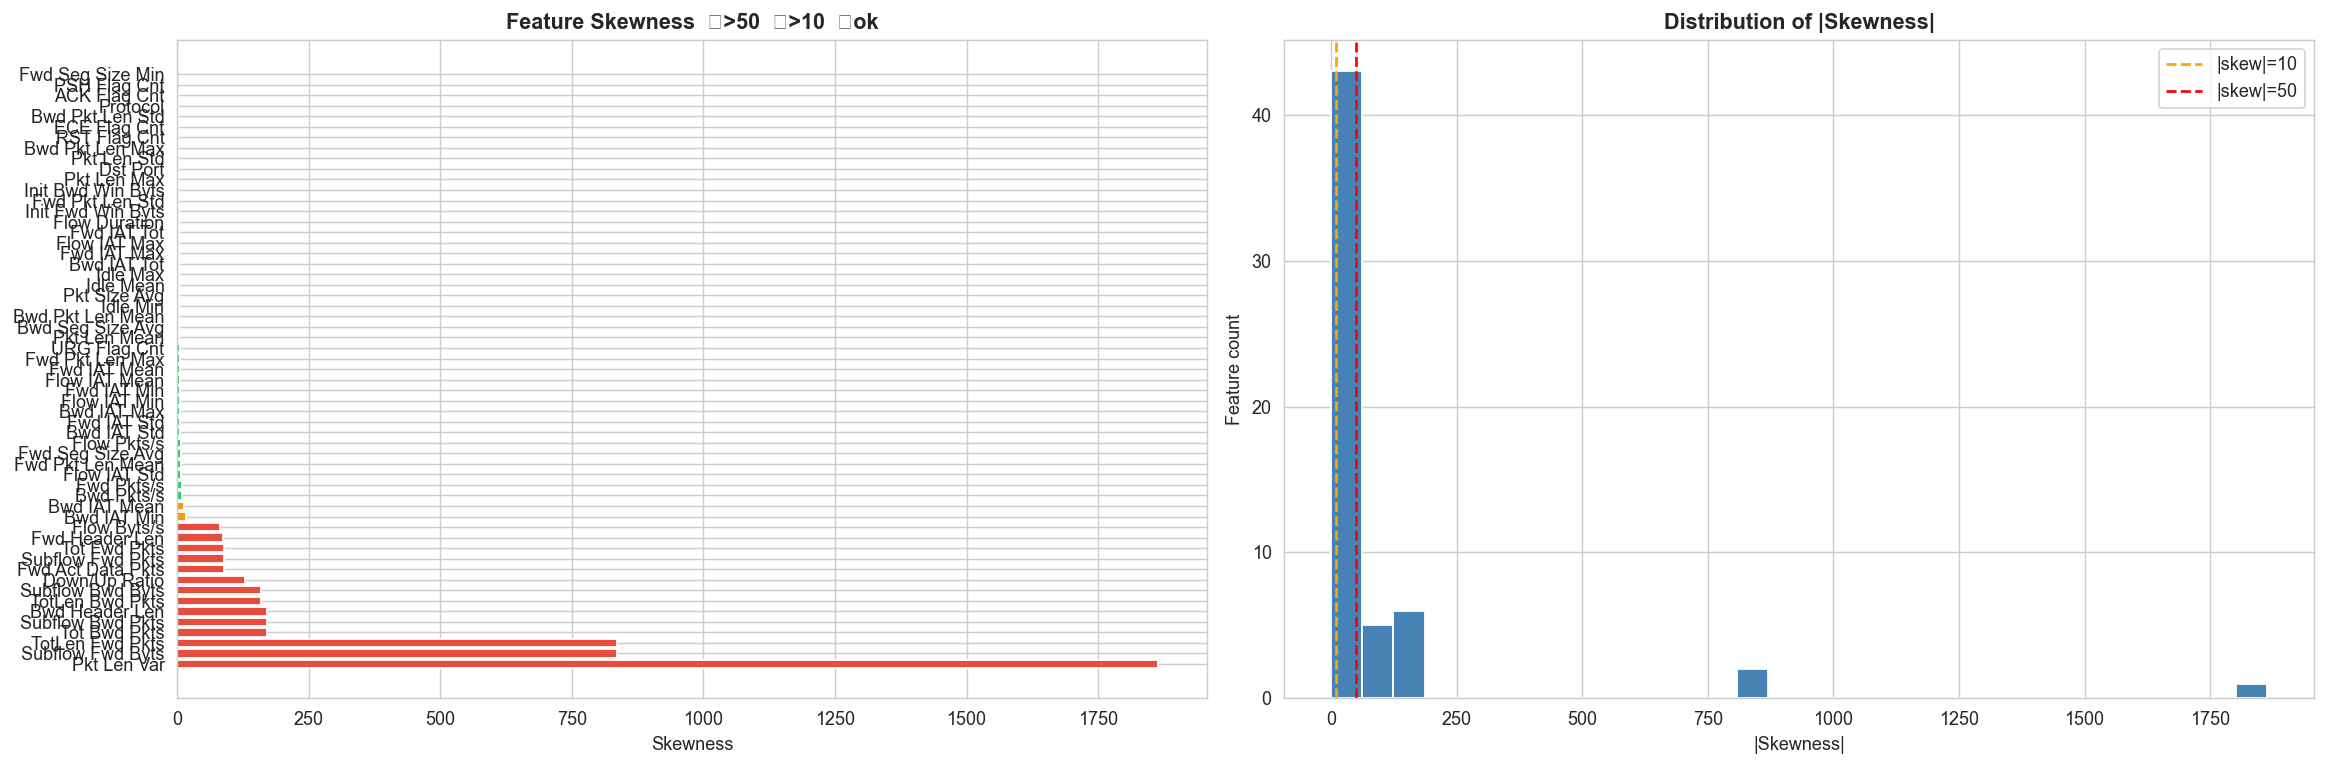

✅ Saved → correlation_analysis/03_skewness_analysis.png


In [6]:
skew_series = X_full_v.skew().sort_values(ascending=False)
print(f'Features with |skew| > 50  : {(skew_series.abs() > 50).sum()}')
print(f'Features with |skew| > 10  : {(skew_series.abs() > 10).sum()} → need PowerTransformer')
print(f'Features with |skew| <= 10 : {(skew_series.abs() <= 10).sum()} → StandardScaler ok')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_sk = ['#e74c3c' if abs(v) > 50 else '#f39c12' if abs(v) > 10 else '#2ecc71'
             for v in skew_series.values]
axes[0].barh(skew_series.index, skew_series.values, color=colors_sk)
axes[0].set_xlabel('Skewness')
axes[0].set_title('Feature Skewness  🔴>50  🟡>10  🟢ok', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.5)

axes[1].hist(skew_series.abs(), bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(10, color='orange', linestyle='--', label='|skew|=10')
axes[1].axvline(50, color='red',    linestyle='--', label='|skew|=50')
axes[1].set_xlabel('|Skewness|')
axes[1].set_ylabel('Feature count')
axes[1].set_title('Distribution of |Skewness|', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_skewness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}03_skewness_analysis.png')


## 7. Feature–Label Correlation (Full Dataset)

Computing feature–label Pearson correlation on FULL dataset...
Done in 11.7s

Rank  Feature                              |r with label|
─────────────────────────────────────────────────────────
1     Fwd Seg Size Min                           0.429296  ██████████
2     Bwd Pkts/s                                 0.260203  ██████
3     Protocol                                   0.233374  █████
4     Fwd Pkt Len Mean                           0.227323  █████
5     Fwd Seg Size Avg                           0.227323  █████
6     ACK Flag Cnt                               0.220465  █████
7     Init Fwd Win Byts                          0.218390  █████
8     Pkt Size Avg                               0.204211  █████
9     Fwd Pkt Len Max                            0.187779  ████
10    Dst Port                                   0.183407  ████
11    Pkt Len Mean                               0.181951  ████
12    Init Bwd Win Byts                          0.180801  ████
13    Bwd Pkt Len Mean  

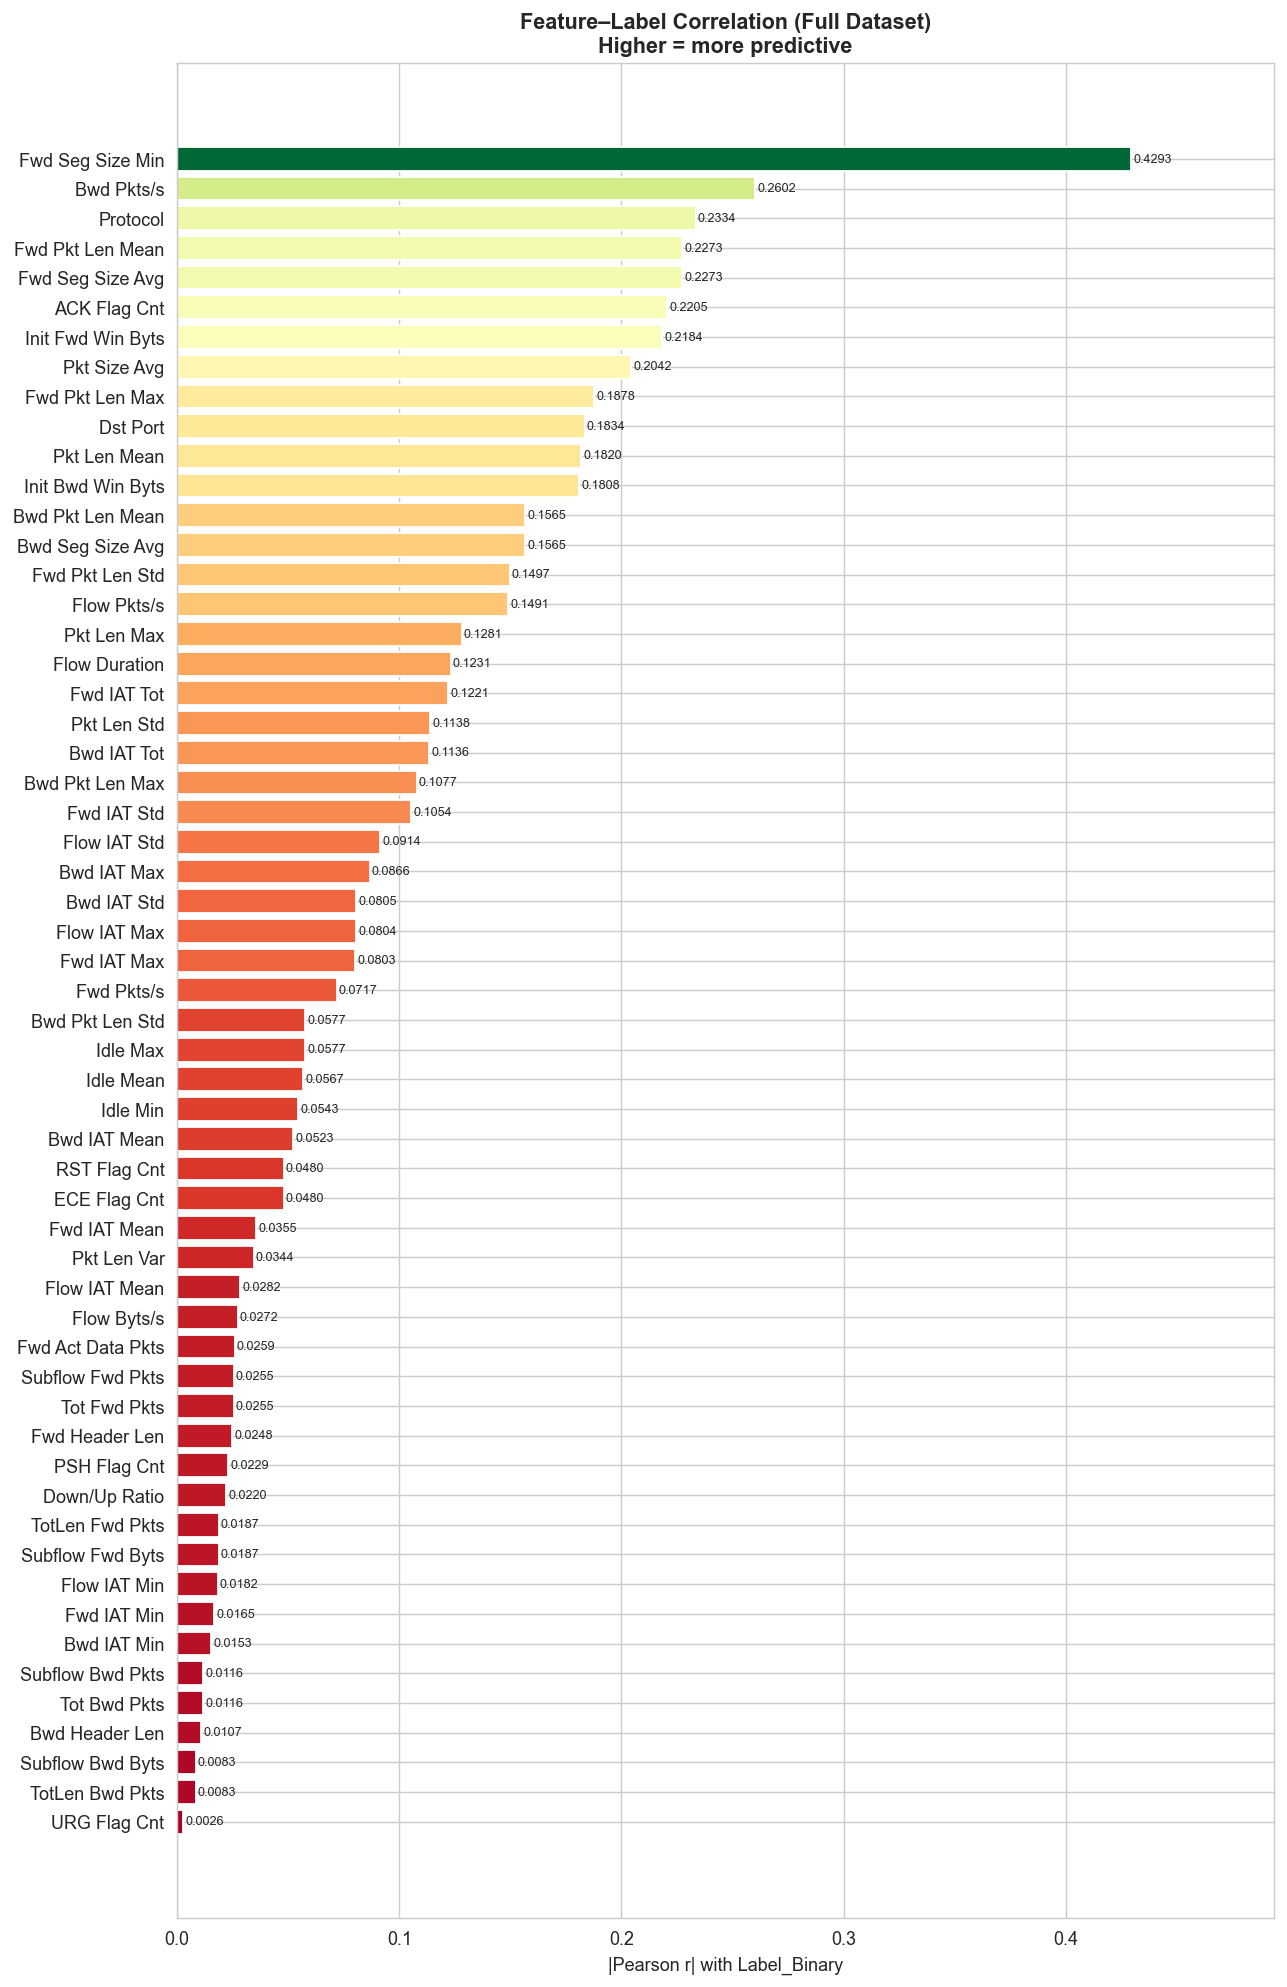

✅ Saved → correlation_analysis/04_feature_label_correlation.png


In [7]:
print('Computing feature–label Pearson correlation on FULL dataset...')
t0 = time.time()
target_corr = X_full_v.corrwith(y_full.astype(float)).abs()
target_corr = target_corr.sort_values(ascending=False)
print(f'Done in {time.time()-t0:.1f}s\n')

print(f'{"Rank":<5} {"Feature":<35} {"|r with label|":>15}')
print('─' * 57)
for rank, (feat, val) in enumerate(target_corr.items(), 1):
    bar = '█' * int(val * 25)
    print(f'{rank:<5} {feat:<35} {val:>15.6f}  {bar}')

target_corr_df = target_corr.reset_index()
target_corr_df.columns = ['Feature', 'corr_with_label']
target_corr_df.to_csv(f'{OUTPUT_DIR}feature_label_correlation.csv', index=False)
tc_lookup = target_corr_df.set_index('Feature')['corr_with_label'].to_dict()
print(f'\n✅ Saved → {OUTPUT_DIR}feature_label_correlation.csv')

fig, ax = plt.subplots(figsize=(10, max(8, len(target_corr) * 0.27)))
cmap_vals = plt.cm.RdYlGn(target_corr.values / max(target_corr.max(), 1e-9))
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=cmap_vals[::-1])
for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=7)
ax.set_xlabel('|Pearson r| with Label_Binary')
ax.set_title('Feature–Label Correlation (Full Dataset)\nHigher = more predictive', fontweight='bold')
ax.set_xlim(0, target_corr.max() * 1.15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}04_feature_label_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}04_feature_label_correlation.png')


## 8. Feature–Feature Correlation Matrix

Computing Pearson correlation matrix on FULL dataset...
   Rows : 16,232,928  |  Features : 57
   ⚠️  This may take 30–90 minutes depending on your hardware.
   Class dist   : {0: np.int64(13484693), 1: np.int64(2748235)}
   Correlation matrix computed in 77.6s
✅ Saved → correlation_analysis/full_correlation_matrix.csv


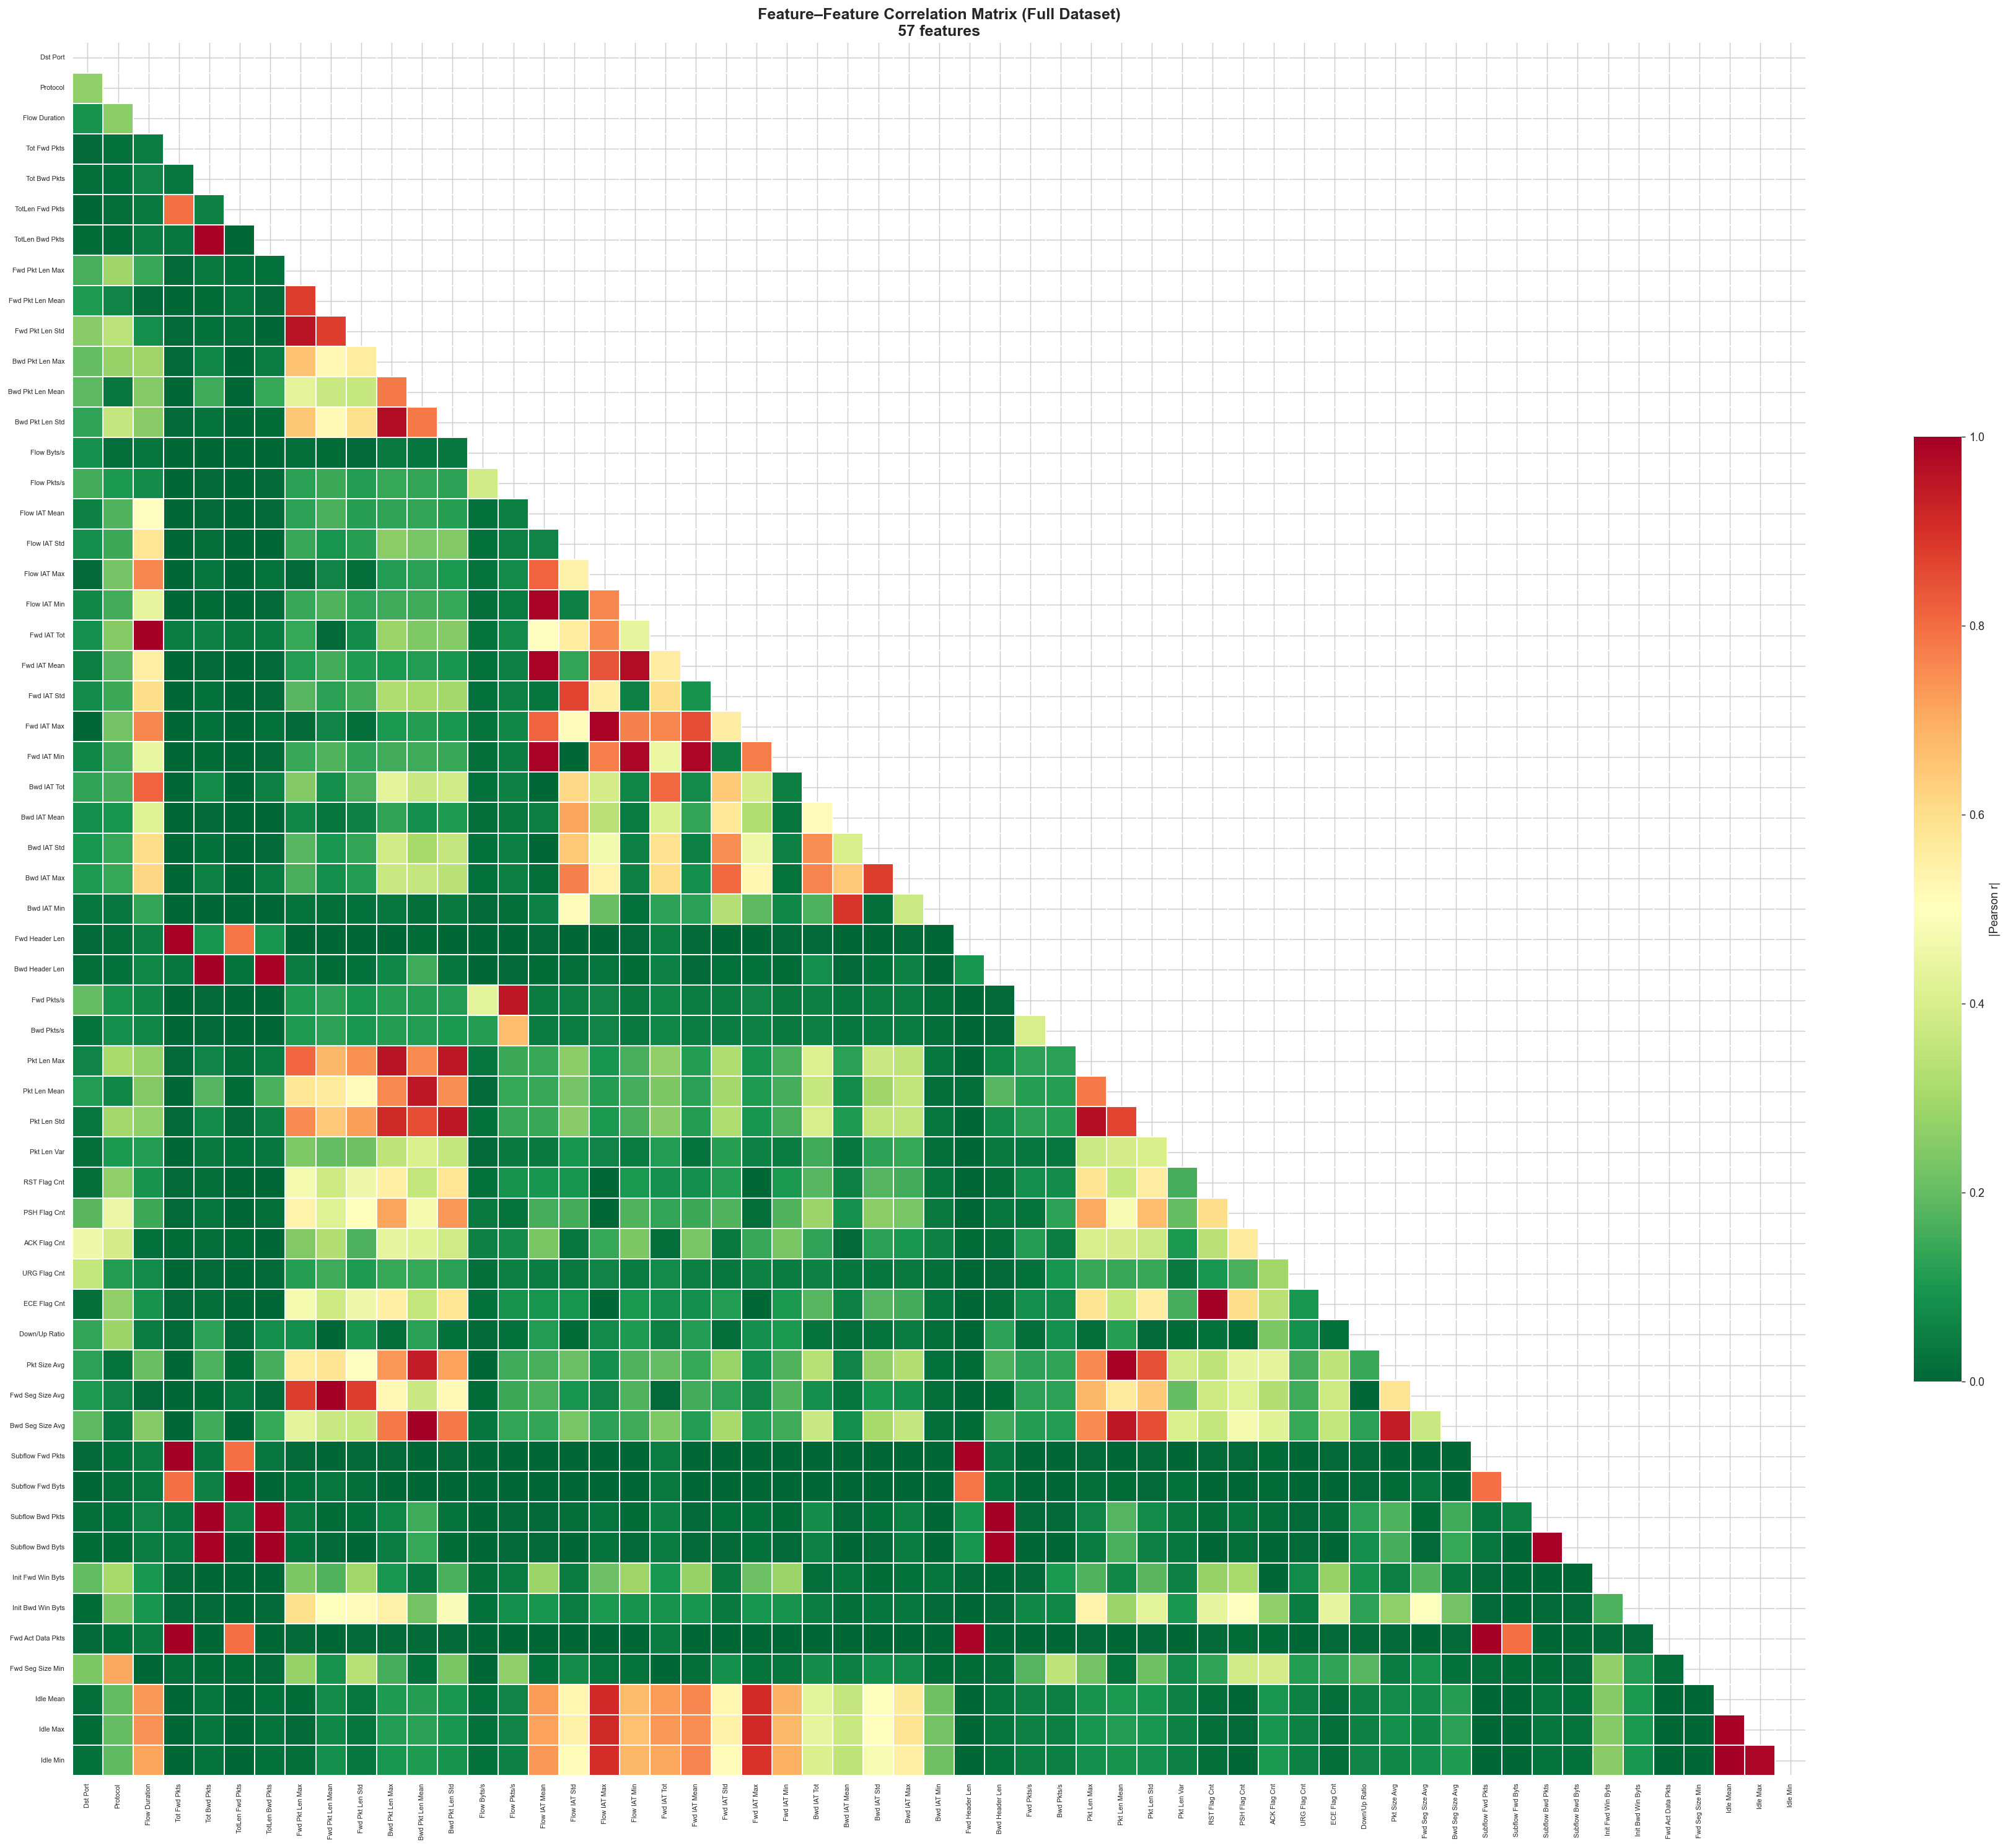

✅ Saved → correlation_analysis/05_full_correlation_heatmap.png


In [8]:
# USE_FULL_DATA = True  → uses all 16M rows (set in Cell 1)
# USE_FULL_DATA = False → uses SAMPLE_N stratified sample

if USE_FULL_DATA:
    print('Computing Pearson correlation matrix on FULL dataset...')
    print(f'   Rows : {len(X_full_v):,}  |  Features : {X_full_v.shape[1]}')
    print('   ⚠️  This may take 30–90 minutes depending on your hardware.')
    X_samp     = X_full_v
    y_samp     = y_full
    sample_idx = X_full_v.index.to_numpy()
else:
    print(f'Computing Pearson correlation matrix on {int(SAMPLE_N):,}-row stratified sample...')
    rng = np.random.RandomState(RANDOM_STATE)
    sample_idx = []
    for cls in y_full.unique():
        cls_idx = y_full[y_full == cls].index.to_numpy()
        n = min(int(SAMPLE_N * (len(cls_idx) / len(y_full))), len(cls_idx))
        sample_idx.extend(rng.choice(cls_idx, n, replace=False))
    X_samp = X_full_v.loc[sample_idx]
    y_samp = y_full.loc[sample_idx]
    print(f'   Sample shape : {X_samp.shape}')

print(f'   Class dist   : {dict(y_samp.value_counts())}')

t0 = time.time()
corr_matrix = X_samp.corr(method='pearson').abs()
print(f'   Correlation matrix computed in {time.time()-t0:.1f}s')

corr_matrix.to_csv(f'{OUTPUT_DIR}full_correlation_matrix.csv')
print(f'✅ Saved → {OUTPUT_DIR}full_correlation_matrix.csv')

mode_label = 'Full Dataset' if USE_FULL_DATA else f'{len(X_samp):,}-row Sample'
fig, ax = plt.subplots(figsize=(28, 24))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdYlGn_r', vmin=0, vmax=1,
    square=True, linewidths=0.1, ax=ax, annot=False,
    cbar_kws={'label': '|Pearson r|', 'shrink': 0.5}
)
ax.set_title(
    f'Feature–Feature Correlation Matrix ({mode_label})\n'
    f'{X_samp.shape[1]} features',
    fontsize=14, fontweight='bold'
)
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6, rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}05_full_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}05_full_correlation_heatmap.png')


## 9. High-Correlation Pairs Analysis

Finding pairs with |r| >= 0.95...

Found 37 pairs with |r| >= 0.95:

#    Feature A                           Feature B                                r
──────────────────────────────────────────────────────────────────────────────────
1    Tot Fwd Pkts                        Subflow Fwd Pkts                    1.0000
2    Fwd Pkt Len Mean                    Fwd Seg Size Avg                    1.0000
3    Bwd Pkt Len Mean                    Bwd Seg Size Avg                    1.0000
4    TotLen Fwd Pkts                     Subflow Fwd Byts                    1.0000
5    Tot Bwd Pkts                        Subflow Bwd Pkts                    1.0000
6    TotLen Bwd Pkts                     Subflow Bwd Byts                    1.0000
7    RST Flag Cnt                        ECE Flag Cnt                        1.0000
8    Subflow Fwd Pkts                    Fwd Act Data Pkts                   0.9992
9    Tot Fwd Pkts                        Fwd Act Data Pkts                   0.9992
10   Tot

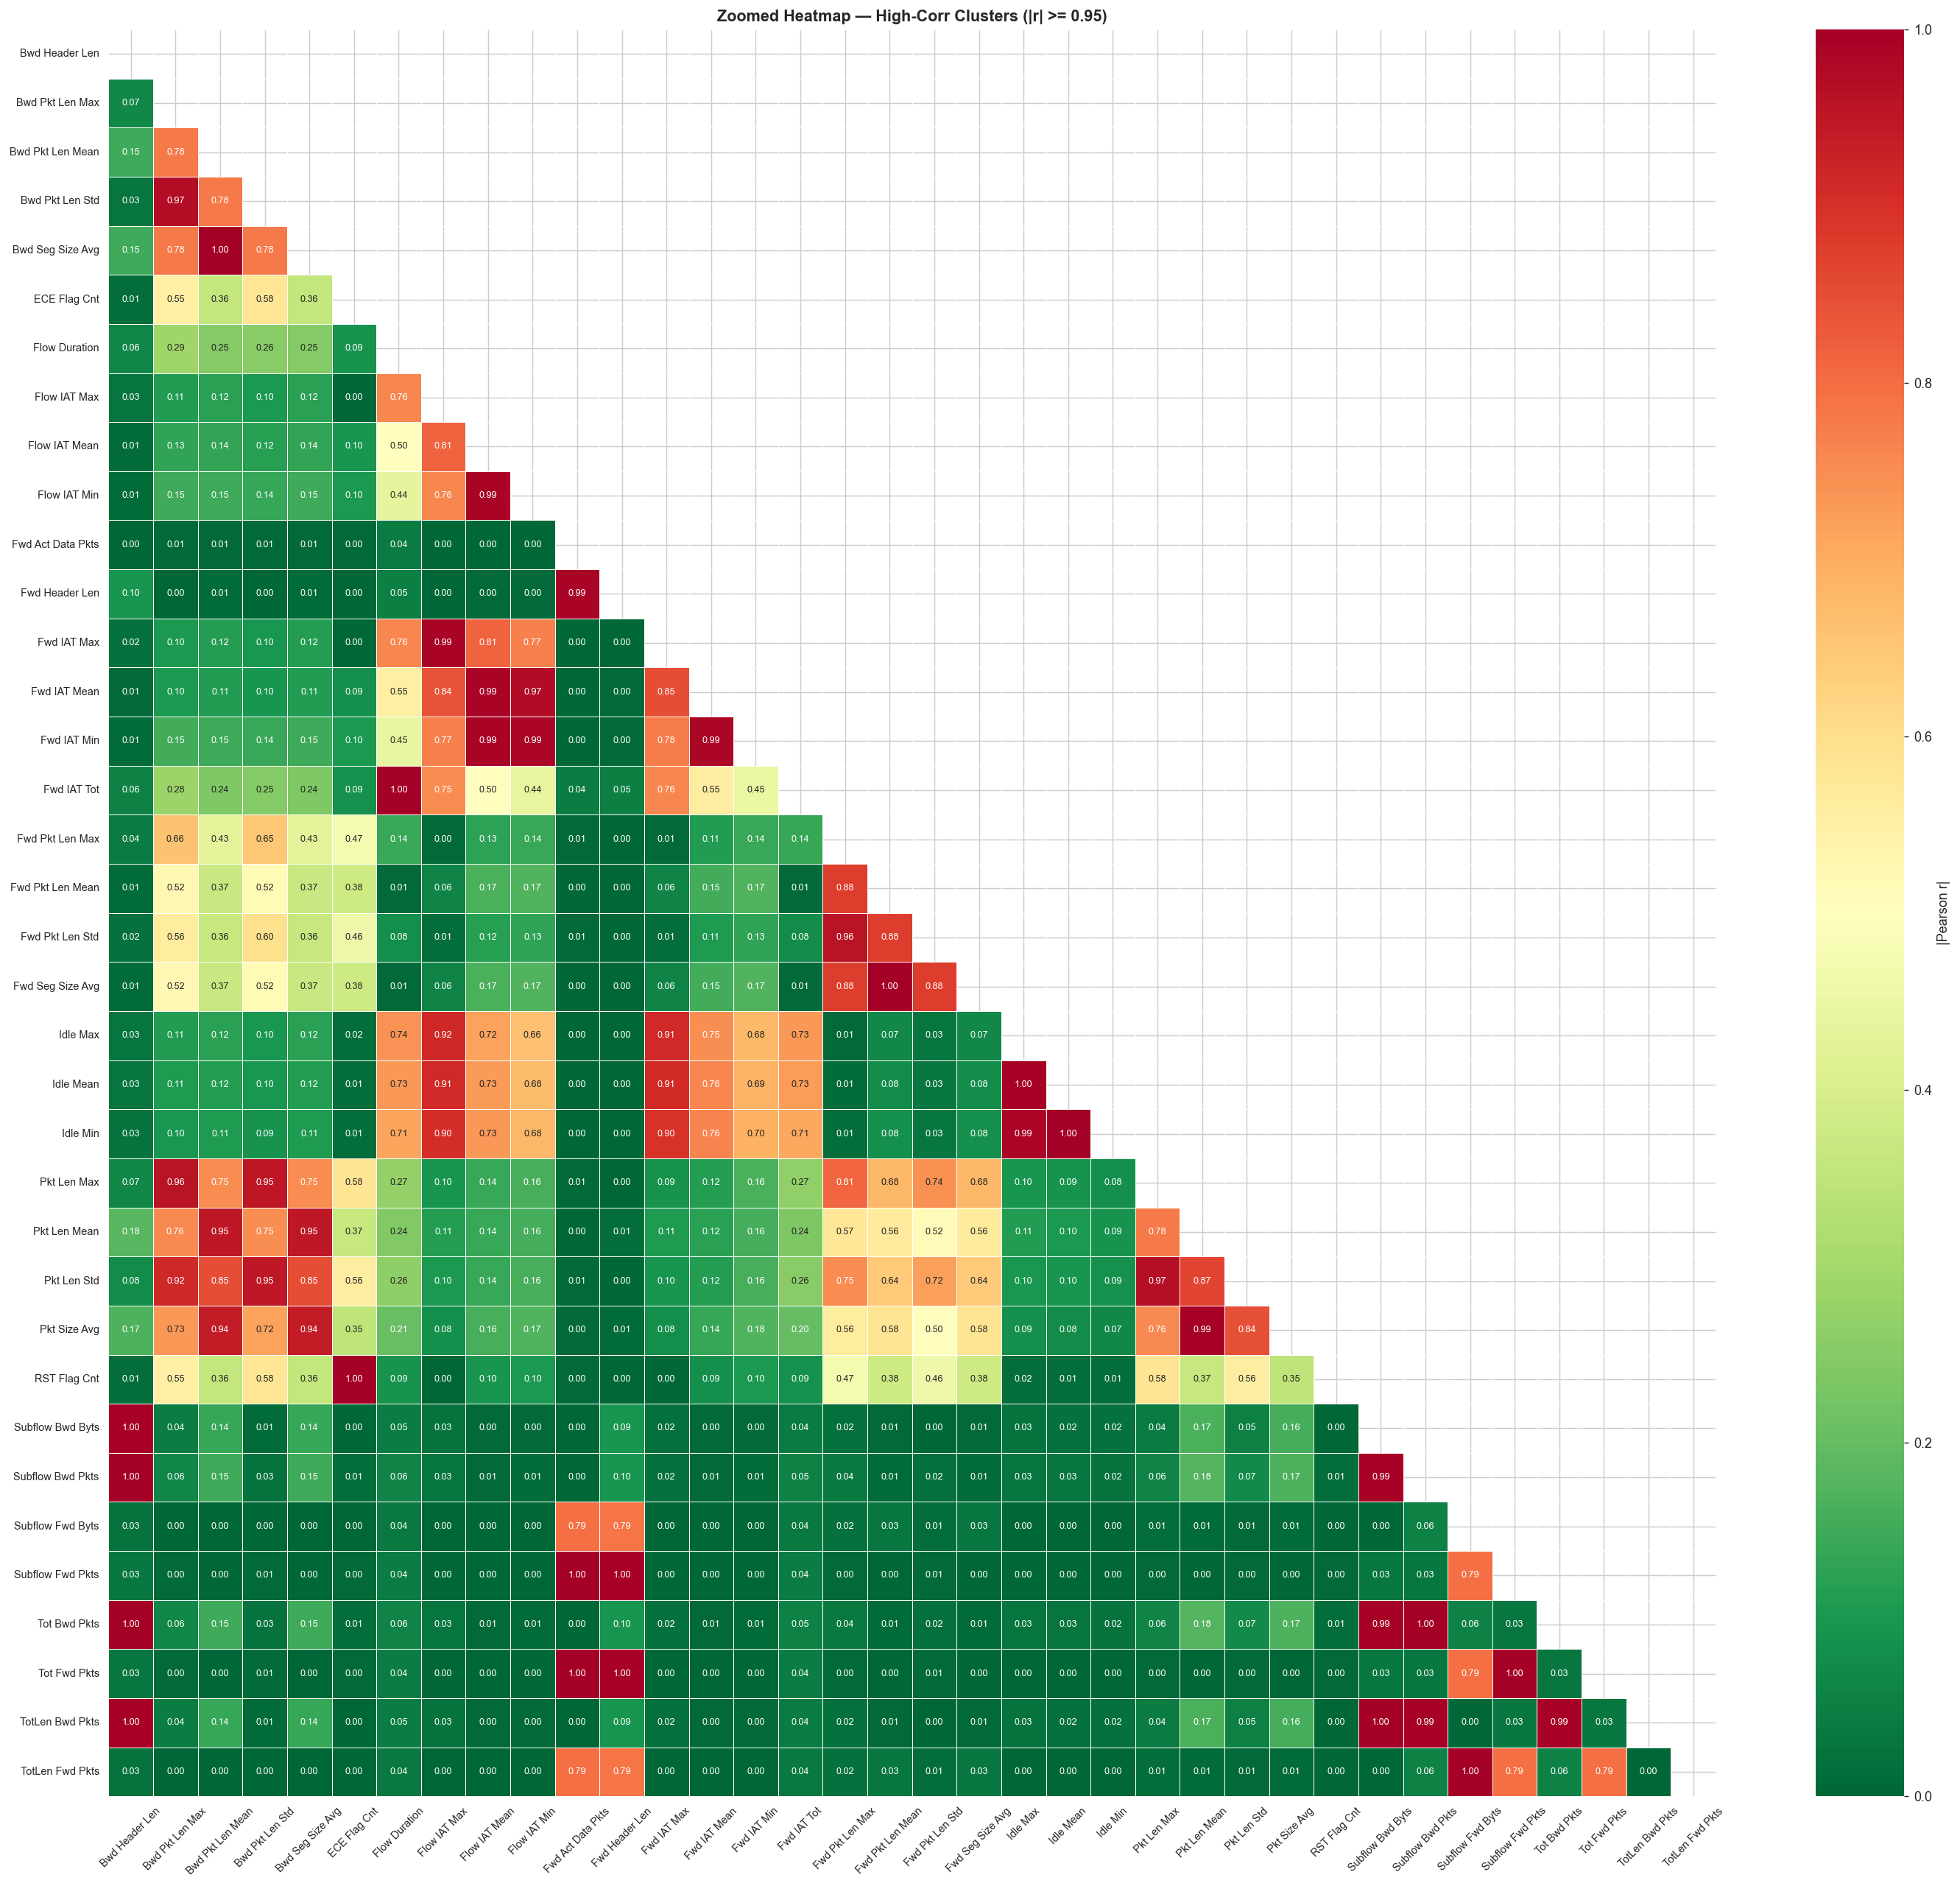

✅ Saved → correlation_analysis/06_high_corr_zoomed_heatmap.png


In [9]:
print(f'Finding pairs with |r| >= {CORR_THRESHOLD}...')

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_A', 'level_1': 'Feature_B', 0: 'Correlation'})
    .query('Correlation >= @CORR_THRESHOLD')
    .sort_values('Correlation', ascending=False)
    .reset_index(drop=True)
)

print(f'\nFound {len(high_corr_pairs)} pairs with |r| >= {CORR_THRESHOLD}:\n')
print(f'{"#":<4} {"Feature A":<35} {"Feature B":<35} {"r":>6}')
print('─' * 82)
for i, row in high_corr_pairs.iterrows():
    print(f'{i+1:<4} {row.Feature_A:<35} {row.Feature_B:<35} {row.Correlation:>6.4f}')

high_corr_pairs.to_csv(f'{OUTPUT_DIR}high_correlation_pairs.csv', index=False)
print(f'\n✅ Saved → {OUTPUT_DIR}high_correlation_pairs.csv')

involved = sorted(set(
    high_corr_pairs['Feature_A'].tolist() + high_corr_pairs['Feature_B'].tolist()
))
print(f'\nFeatures involved in high-corr pairs: {len(involved)}')

if involved:
    sub_corr = corr_matrix.loc[involved, involved]
    fig, ax = plt.subplots(figsize=(max(12, len(involved) * 0.62),
                                    max(10, len(involved) * 0.55)))
    mask2 = np.triu(np.ones_like(sub_corr, dtype=bool))
    sns.heatmap(
        sub_corr, mask=mask2, annot=True, fmt='.2f',
        cmap='RdYlGn_r', vmin=0, vmax=1,
        linewidths=0.5, ax=ax, annot_kws={'size': 7},
        cbar_kws={'label': '|Pearson r|'}
    )
    ax.set_title(
        f'Zoomed Heatmap — High-Corr Clusters (|r| >= {CORR_THRESHOLD})',
        fontsize=12, fontweight='bold'
    )
    ax.tick_params(axis='x', labelsize=8, rotation=45)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}06_high_corr_zoomed_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {OUTPUT_DIR}06_high_corr_zoomed_heatmap.png')


## 10. Greedy Drop Decision — Keep Most Predictive Feature per Pair

Greedy drop: for each correlated pair, drop the one less correlated with label

  KEEP Tot Fwd Pkts                        (r=0.0255)  DROP Subflow Fwd Pkts                    (r=0.0255)  pair=1.0000
  KEEP Fwd Pkt Len Mean                    (r=0.2273)  DROP Fwd Seg Size Avg                    (r=0.2273)  pair=1.0000
  KEEP Bwd Pkt Len Mean                    (r=0.1565)  DROP Bwd Seg Size Avg                    (r=0.1565)  pair=1.0000
  KEEP TotLen Fwd Pkts                     (r=0.0187)  DROP Subflow Fwd Byts                    (r=0.0187)  pair=1.0000
  KEEP Tot Bwd Pkts                        (r=0.0116)  DROP Subflow Bwd Pkts                    (r=0.0116)  pair=1.0000
  KEEP Subflow Bwd Byts                    (r=0.0083)  DROP TotLen Bwd Pkts                     (r=0.0083)  pair=1.0000
  KEEP RST Flag Cnt                        (r=0.0480)  DROP ECE Flag Cnt                        (r=0.0480)  pair=1.0000
  KEEP Fwd Act Data Pkts                   (r=0.0259)  DROP Tot Fwd Pkts        

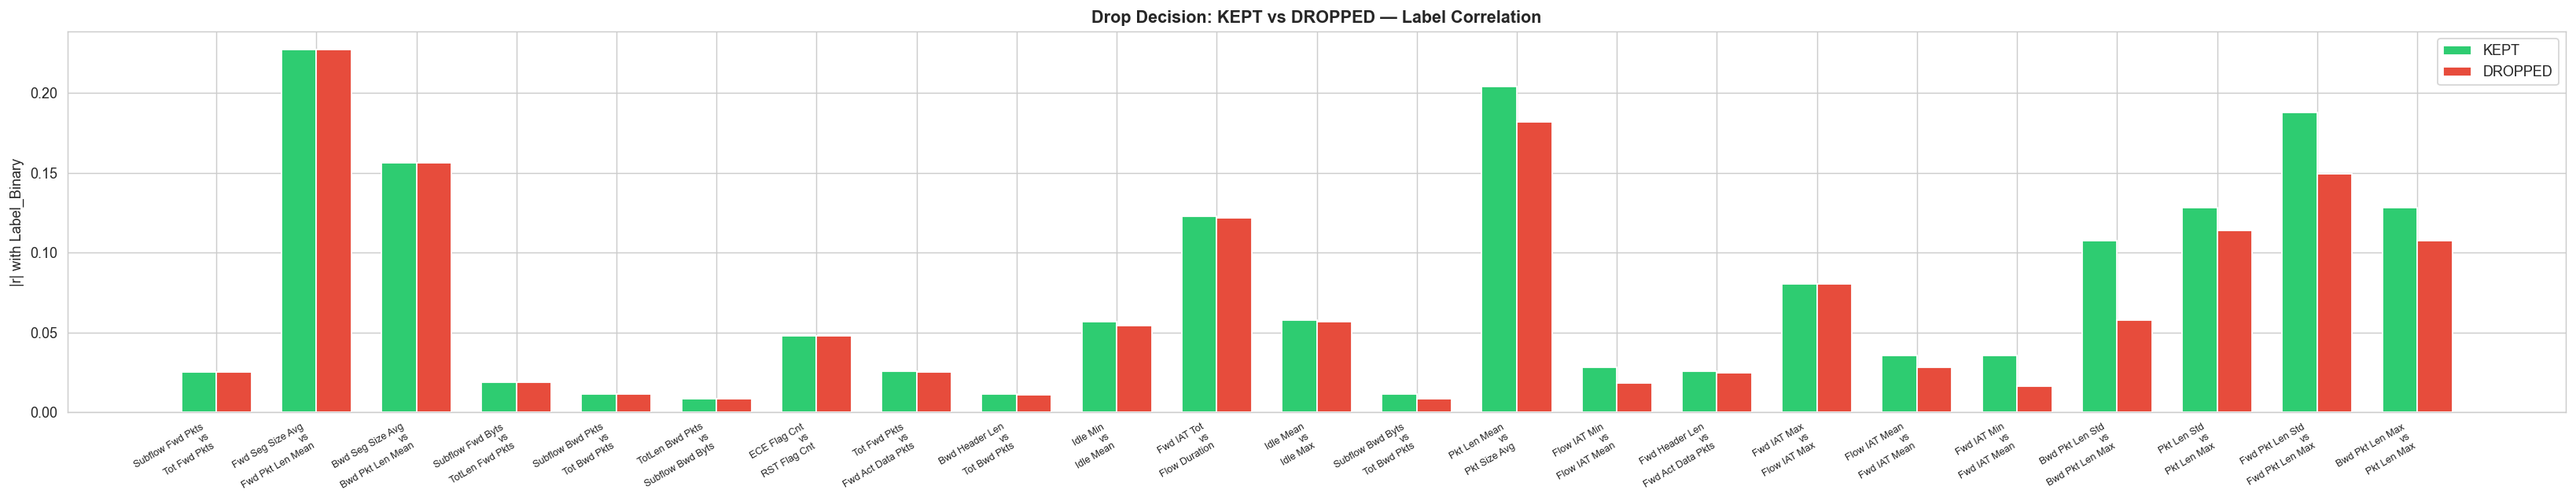

✅ Saved → correlation_analysis/07_drop_decisions.png


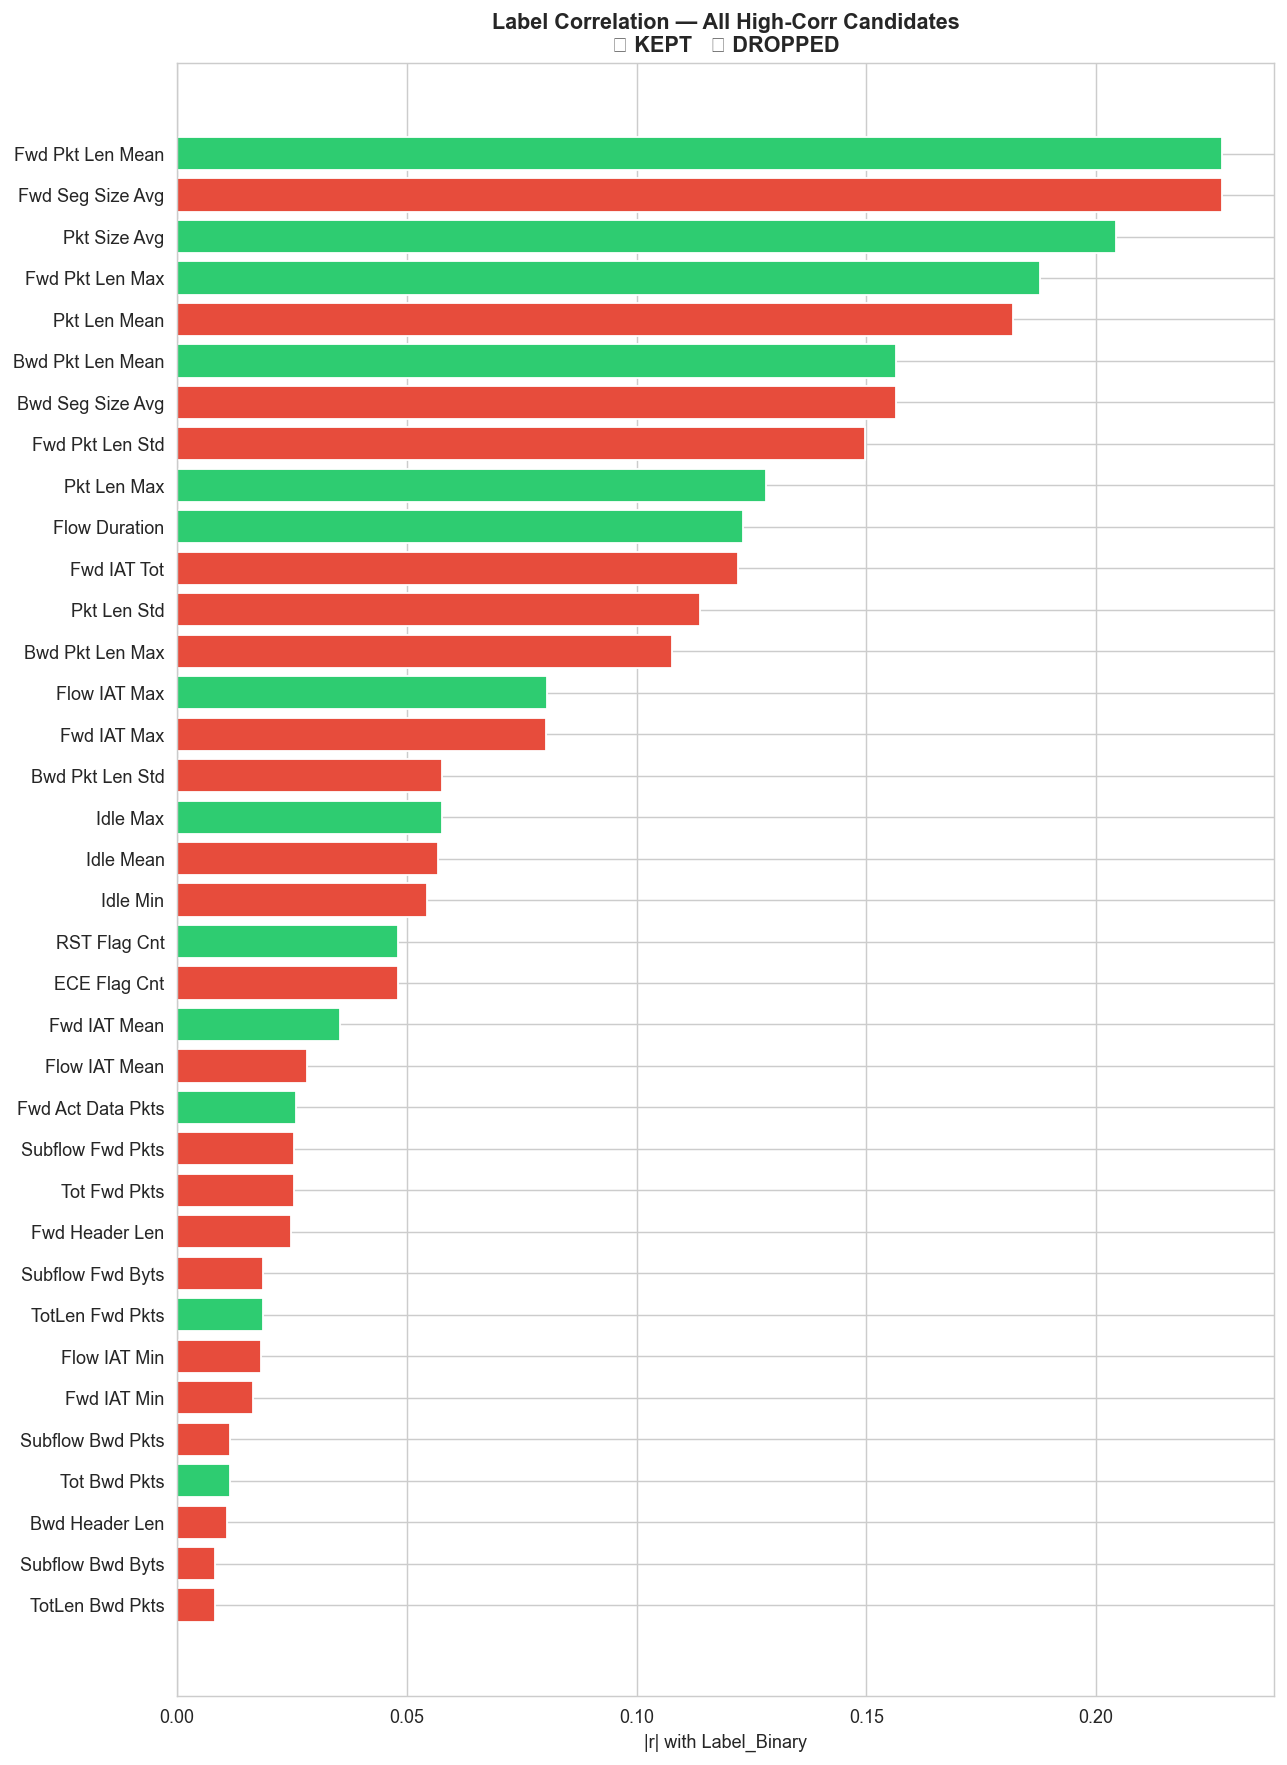

✅ Saved → correlation_analysis/08_kept_vs_dropped_label_corr.png


In [10]:
print('Greedy drop: for each correlated pair, drop the one less correlated with label\n')

to_drop  = set()
drop_log = []

for _, row in high_corr_pairs.iterrows():
    A, B = row['Feature_A'], row['Feature_B']
    if A in to_drop and B in to_drop:
        continue
    corr_A = tc_lookup.get(A, 0)
    corr_B = tc_lookup.get(B, 0)

    if A in to_drop:
        pass  # A already gone, B survives
    elif B in to_drop:
        pass  # B already gone, A survives
    elif corr_A >= corr_B:
        to_drop.add(B)
        drop_log.append({'dropped': B, 'kept': A,
                         'pair_r': round(row.Correlation, 4),
                         'dropped_label_r': round(corr_B, 6),
                         'kept_label_r': round(corr_A, 6),
                         'label_r_diff': round(corr_A - corr_B, 6)})
        print(f'  KEEP {A:<35} (r={corr_A:.4f})  DROP {B:<35} (r={corr_B:.4f})  pair={row.Correlation:.4f}')
    else:
        to_drop.add(A)
        drop_log.append({'dropped': A, 'kept': B,
                         'pair_r': round(row.Correlation, 4),
                         'dropped_label_r': round(corr_A, 6),
                         'kept_label_r': round(corr_B, 6),
                         'label_r_diff': round(corr_B - corr_A, 6)})
        print(f'  KEEP {B:<35} (r={corr_B:.4f})  DROP {A:<35} (r={corr_A:.4f})  pair={row.Correlation:.4f}')

drop_df = pd.DataFrame(drop_log)
drop_df.to_csv(f'{OUTPUT_DIR}drop_decisions.csv', index=False)

print(f'\n🗑️  Total to drop : {len(to_drop)}')
print(f'   {sorted(to_drop)}')
print(f'\n✅ Saved → {OUTPUT_DIR}drop_decisions.csv')

if len(drop_df) > 0:
    # Plot 1: kept vs dropped label-r per decision
    x = np.arange(len(drop_df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(10, len(drop_df) * 1.1), 5))
    ax.bar(x - width/2, drop_df['kept_label_r'],    width, label='KEPT',    color='#2ecc71')
    ax.bar(x + width/2, drop_df['dropped_label_r'], width, label='DROPPED', color='#e74c3c')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['dropped']}\nvs\n{r['kept']}" for _, r in drop_df.iterrows()],
        rotation=30, ha='right', fontsize=7
    )
    ax.set_ylabel('|r| with Label_Binary')
    ax.set_title('Drop Decision: KEPT vs DROPPED — Label Correlation', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}07_drop_decisions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {OUTPUT_DIR}07_drop_decisions.png')

    # Plot 2: all involved features colored keep/drop
    tc_inv = {f: tc_lookup.get(f, 0) for f in involved}
    tc_sorted = dict(sorted(tc_inv.items(), key=lambda x: x[1], reverse=True))
    colors_inv = ['#e74c3c' if f in to_drop else '#2ecc71' for f in tc_sorted]
    fig2, ax2 = plt.subplots(figsize=(10, max(6, len(involved) * 0.38)))
    ax2.barh(list(tc_sorted.keys())[::-1], list(tc_sorted.values())[::-1], color=colors_inv[::-1])
    ax2.set_xlabel('|r| with Label_Binary')
    ax2.set_title('Label Correlation — All High-Corr Candidates\n🟢 KEPT   🔴 DROPPED', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}08_kept_vs_dropped_label_corr.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved → {OUTPUT_DIR}08_kept_vs_dropped_label_corr.png')


## 11. Apply Drop — Update X_full & Scaling Configs

In [11]:
print('=' * 70)
print('APPLYING FEATURE DROP')
print('=' * 70)

ALL_DROPS = set(VARIANCE_DROP) | to_drop
before_n  = X_full.shape[1]
X_full    = X_full.drop(columns=list(ALL_DROPS), errors='ignore')

print(f'\n   Variance drops    : {len(VARIANCE_DROP)}  {sorted(VARIANCE_DROP)}')
print(f'   Correlation drops : {len(to_drop)}  {sorted(to_drop)}')
print(f'   Features before   : {before_n}')
print(f'   Features after    : {X_full.shape[1]}')
print(f'   Total removed     : {before_n - X_full.shape[1]}')

POWER_TRANSFORMER_FEATURES = [f for f in POWER_TRANSFORMER_FEATURES if f not in ALL_DROPS]
STANDARD_SCALER_FEATURES   = [f for f in STANDARD_SCALER_FEATURES   if f not in ALL_DROPS]
NO_SCALING_FEATURES        = [f for f in NO_SCALING_FEATURES        if f not in ALL_DROPS]

print(f'\n✅ Scaling configs updated:')
print(f'   PowerTransformer  : {len(POWER_TRANSFORMER_FEATURES)} features')
print(f'   StandardScaler    : {len(STANDARD_SCALER_FEATURES)} features')
print(f'   No-scale (flags)  : {len(NO_SCALING_FEATURES)} features')

pd.DataFrame({'feature': X_full.columns.tolist()}).to_csv(
    f'{OUTPUT_DIR}surviving_features.csv', index=False
)
print(f'\n✅ Saved → {OUTPUT_DIR}surviving_features.csv')

print('\nSurviving features:')
for i, f in enumerate(X_full.columns, 1):
    print(f'   {i:2d}. {f}')


APPLYING FEATURE DROP

   Variance drops    : 0  []
   Correlation drops : 23  ['Bwd Header Len', 'Bwd Pkt Len Max', 'Bwd Pkt Len Std', 'Bwd Seg Size Avg', 'ECE Flag Cnt', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd Header Len', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd IAT Tot', 'Fwd Pkt Len Std', 'Fwd Seg Size Avg', 'Idle Mean', 'Idle Min', 'Pkt Len Mean', 'Pkt Len Std', 'Subflow Bwd Byts', 'Subflow Bwd Pkts', 'Subflow Fwd Byts', 'Subflow Fwd Pkts', 'Tot Fwd Pkts', 'TotLen Bwd Pkts']
   Features before   : 57
   Features after    : 34
   Total removed     : 23

✅ Scaling configs updated:
   PowerTransformer  : 28 features
   StandardScaler    : 1 features
   No-scale (flags)  : 5 features

✅ Saved → correlation_analysis/surviving_features.csv

Surviving features:
    1. Dst Port
    2. Protocol
    3. Flow Duration
    4. Tot Bwd Pkts
    5. TotLen Fwd Pkts
    6. Fwd Pkt Len Max
    7. Fwd Pkt Len Mean
    8. Bwd Pkt Len Mean
    9. Flow Byts/s
   10. Flow Pkts/s
   11. Flow IAT Std
   12. Flow 

## 12. Pairplot — Top 8 Surviving Features (2k sample)

Top 8 surviving features by label correlation:
  ['Fwd Seg Size Min', 'Bwd Pkts/s', 'Protocol', 'Fwd Pkt Len Mean', 'ACK Flag Cnt', 'Init Fwd Win Byts', 'Pkt Size Avg', 'Fwd Pkt Len Max']


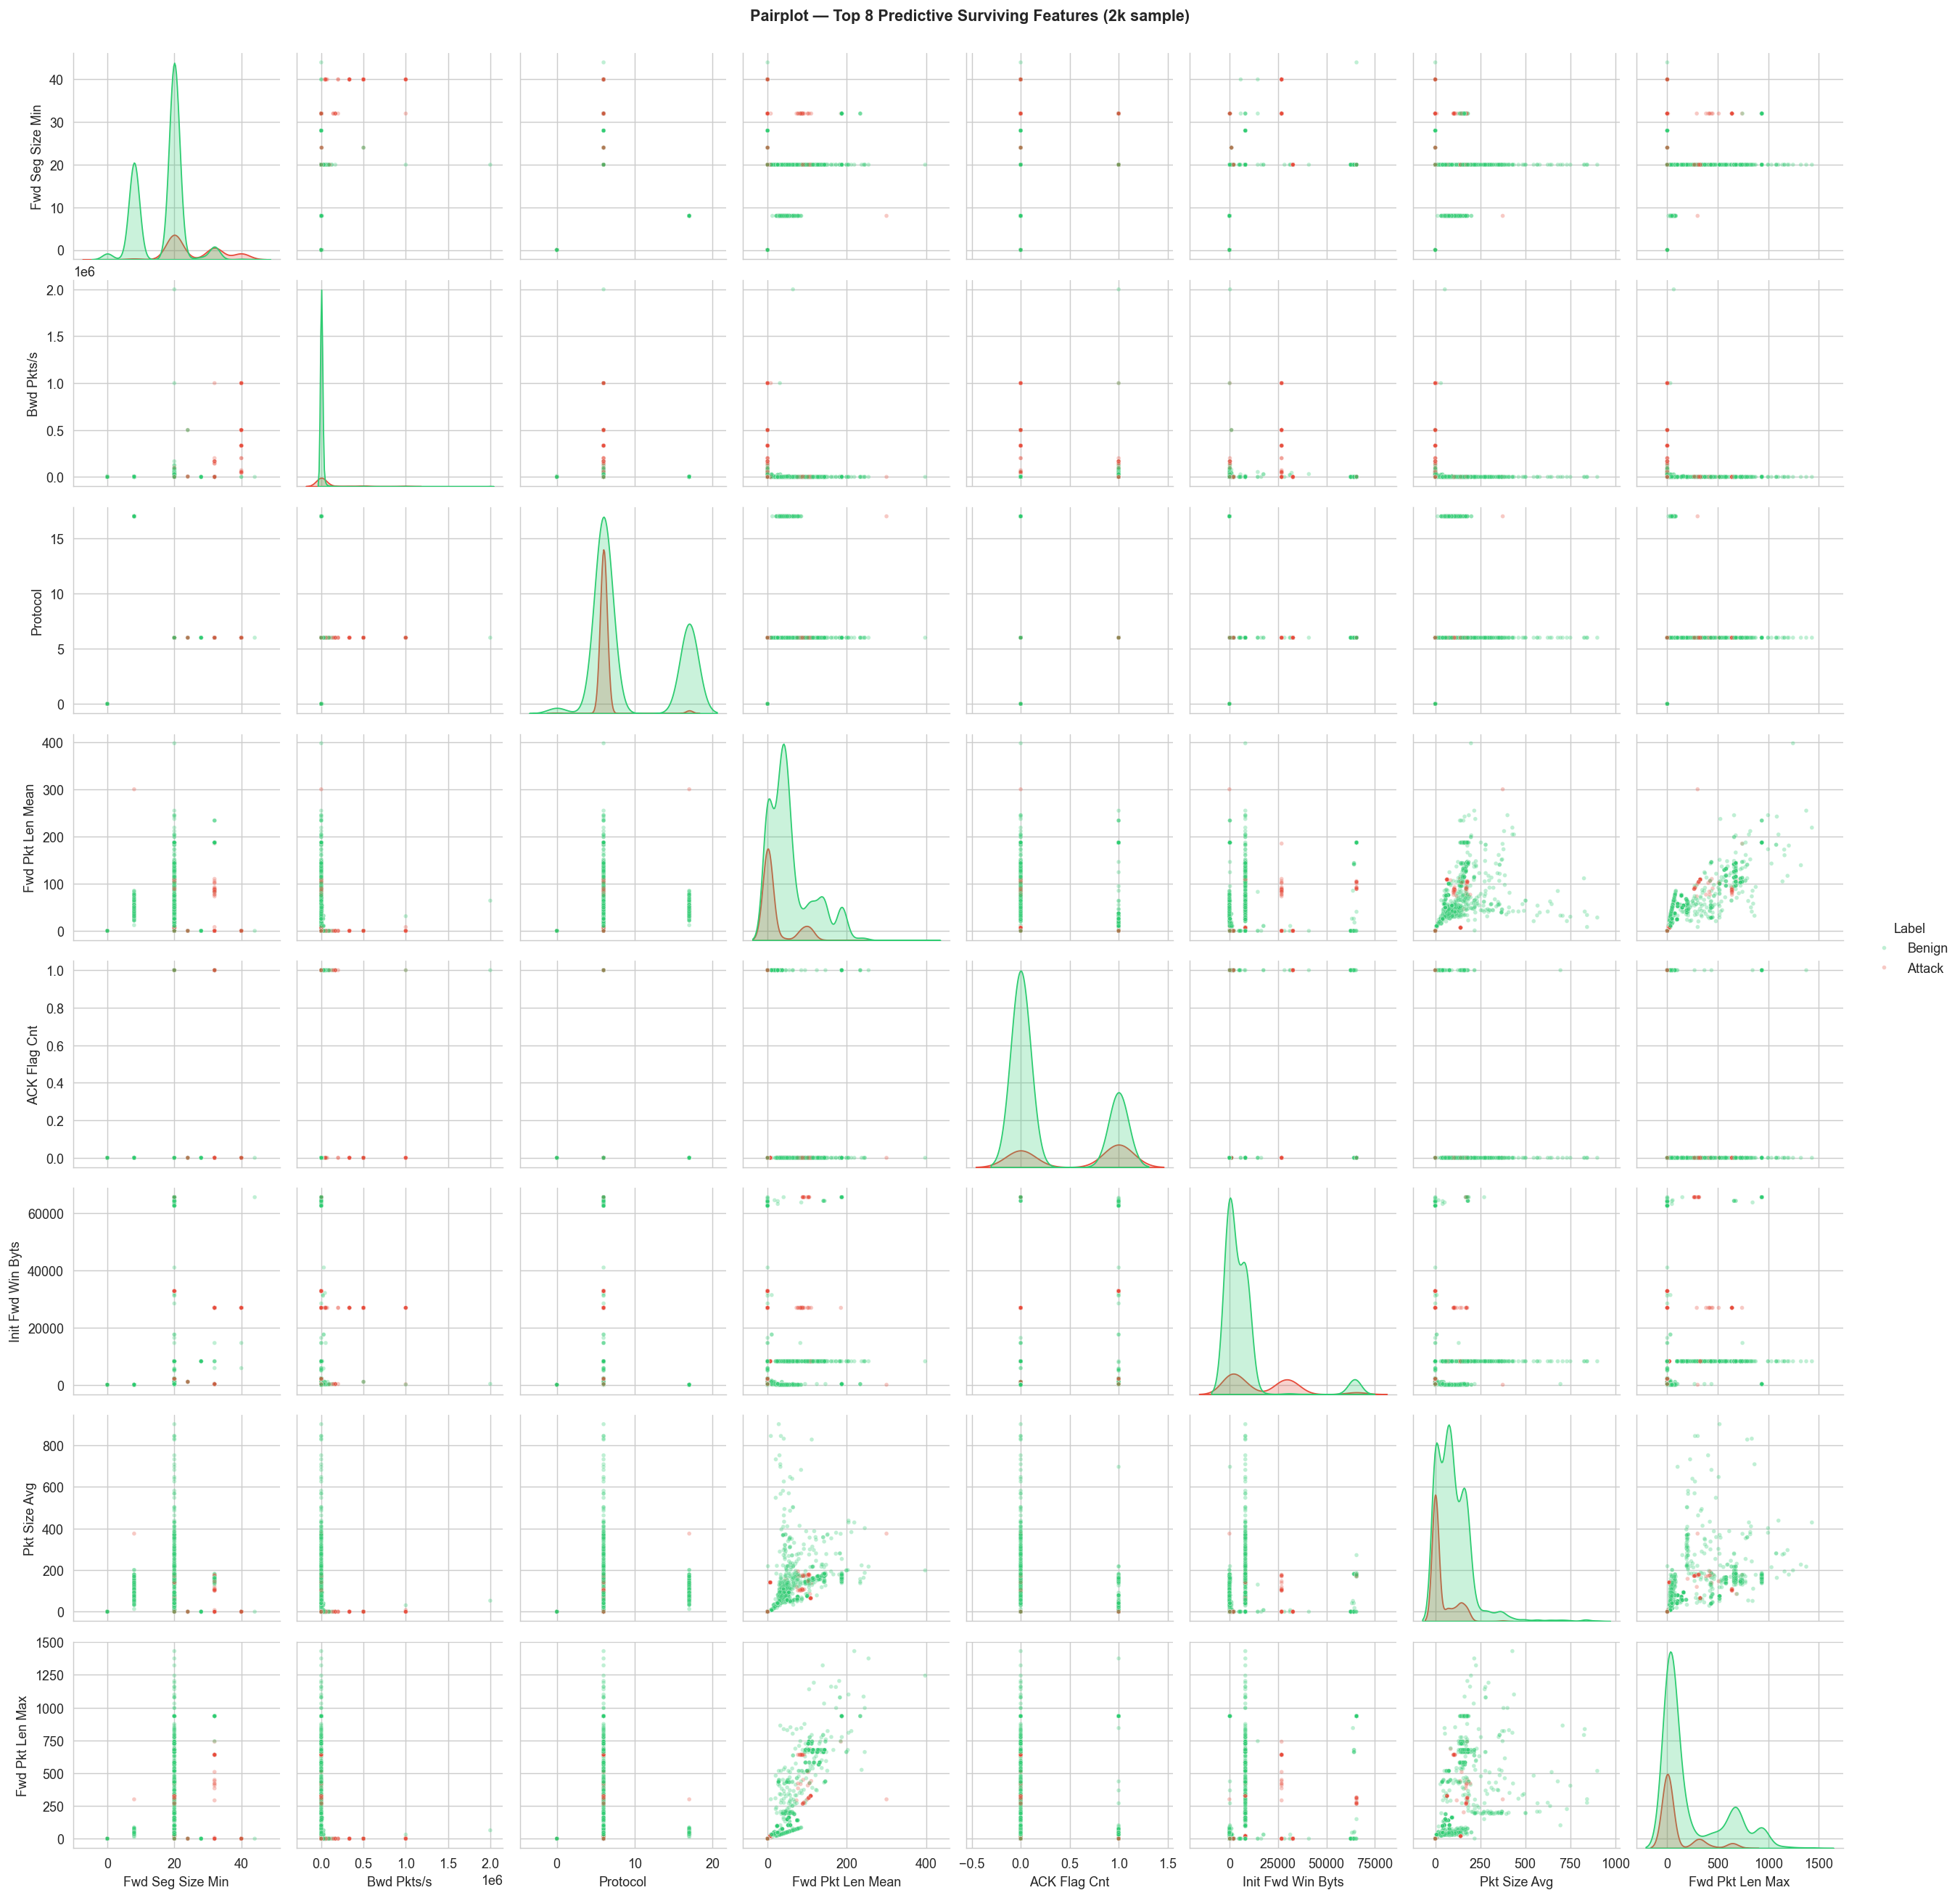

✅ Saved → correlation_analysis/09_pairplot_top8.png


In [12]:
top8 = (
    target_corr_df[target_corr_df['Feature'].isin(X_full.columns)]
    .sort_values('corr_with_label', ascending=False)
    .head(8)['Feature'].tolist()
)
print(f'Top 8 surviving features by label correlation:\n  {top8}')

pair_idx = (
    pd.Series(y_full.index)
    .sample(min(2000, len(y_full)), random_state=RANDOM_STATE)
    .values
)
pair_df = X_full.loc[pair_idx, top8].copy()
pair_df['Label'] = y_full.loc[pair_idx].map({0: 'Benign', 1: 'Attack'}).values

g = sns.pairplot(
    pair_df, hue='Label', vars=top8,
    palette={'Benign': '#2ecc71', 'Attack': '#e74c3c'},
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot — Top 8 Predictive Surviving Features (2k sample)',
               y=1.01, fontsize=12, fontweight='bold')
plt.savefig(f'{OUTPUT_DIR}09_pairplot_top8.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}09_pairplot_top8.png')


## 13. Post-Drop Correlation Check — Verify No Redundancy Remains

Post-drop correlation check on surviving features...
   Using full dataset: (16232928, 34)

✅ CLEAN — No pairs remain above |r| = 0.95

Max remaining |r| between features: 0.9469


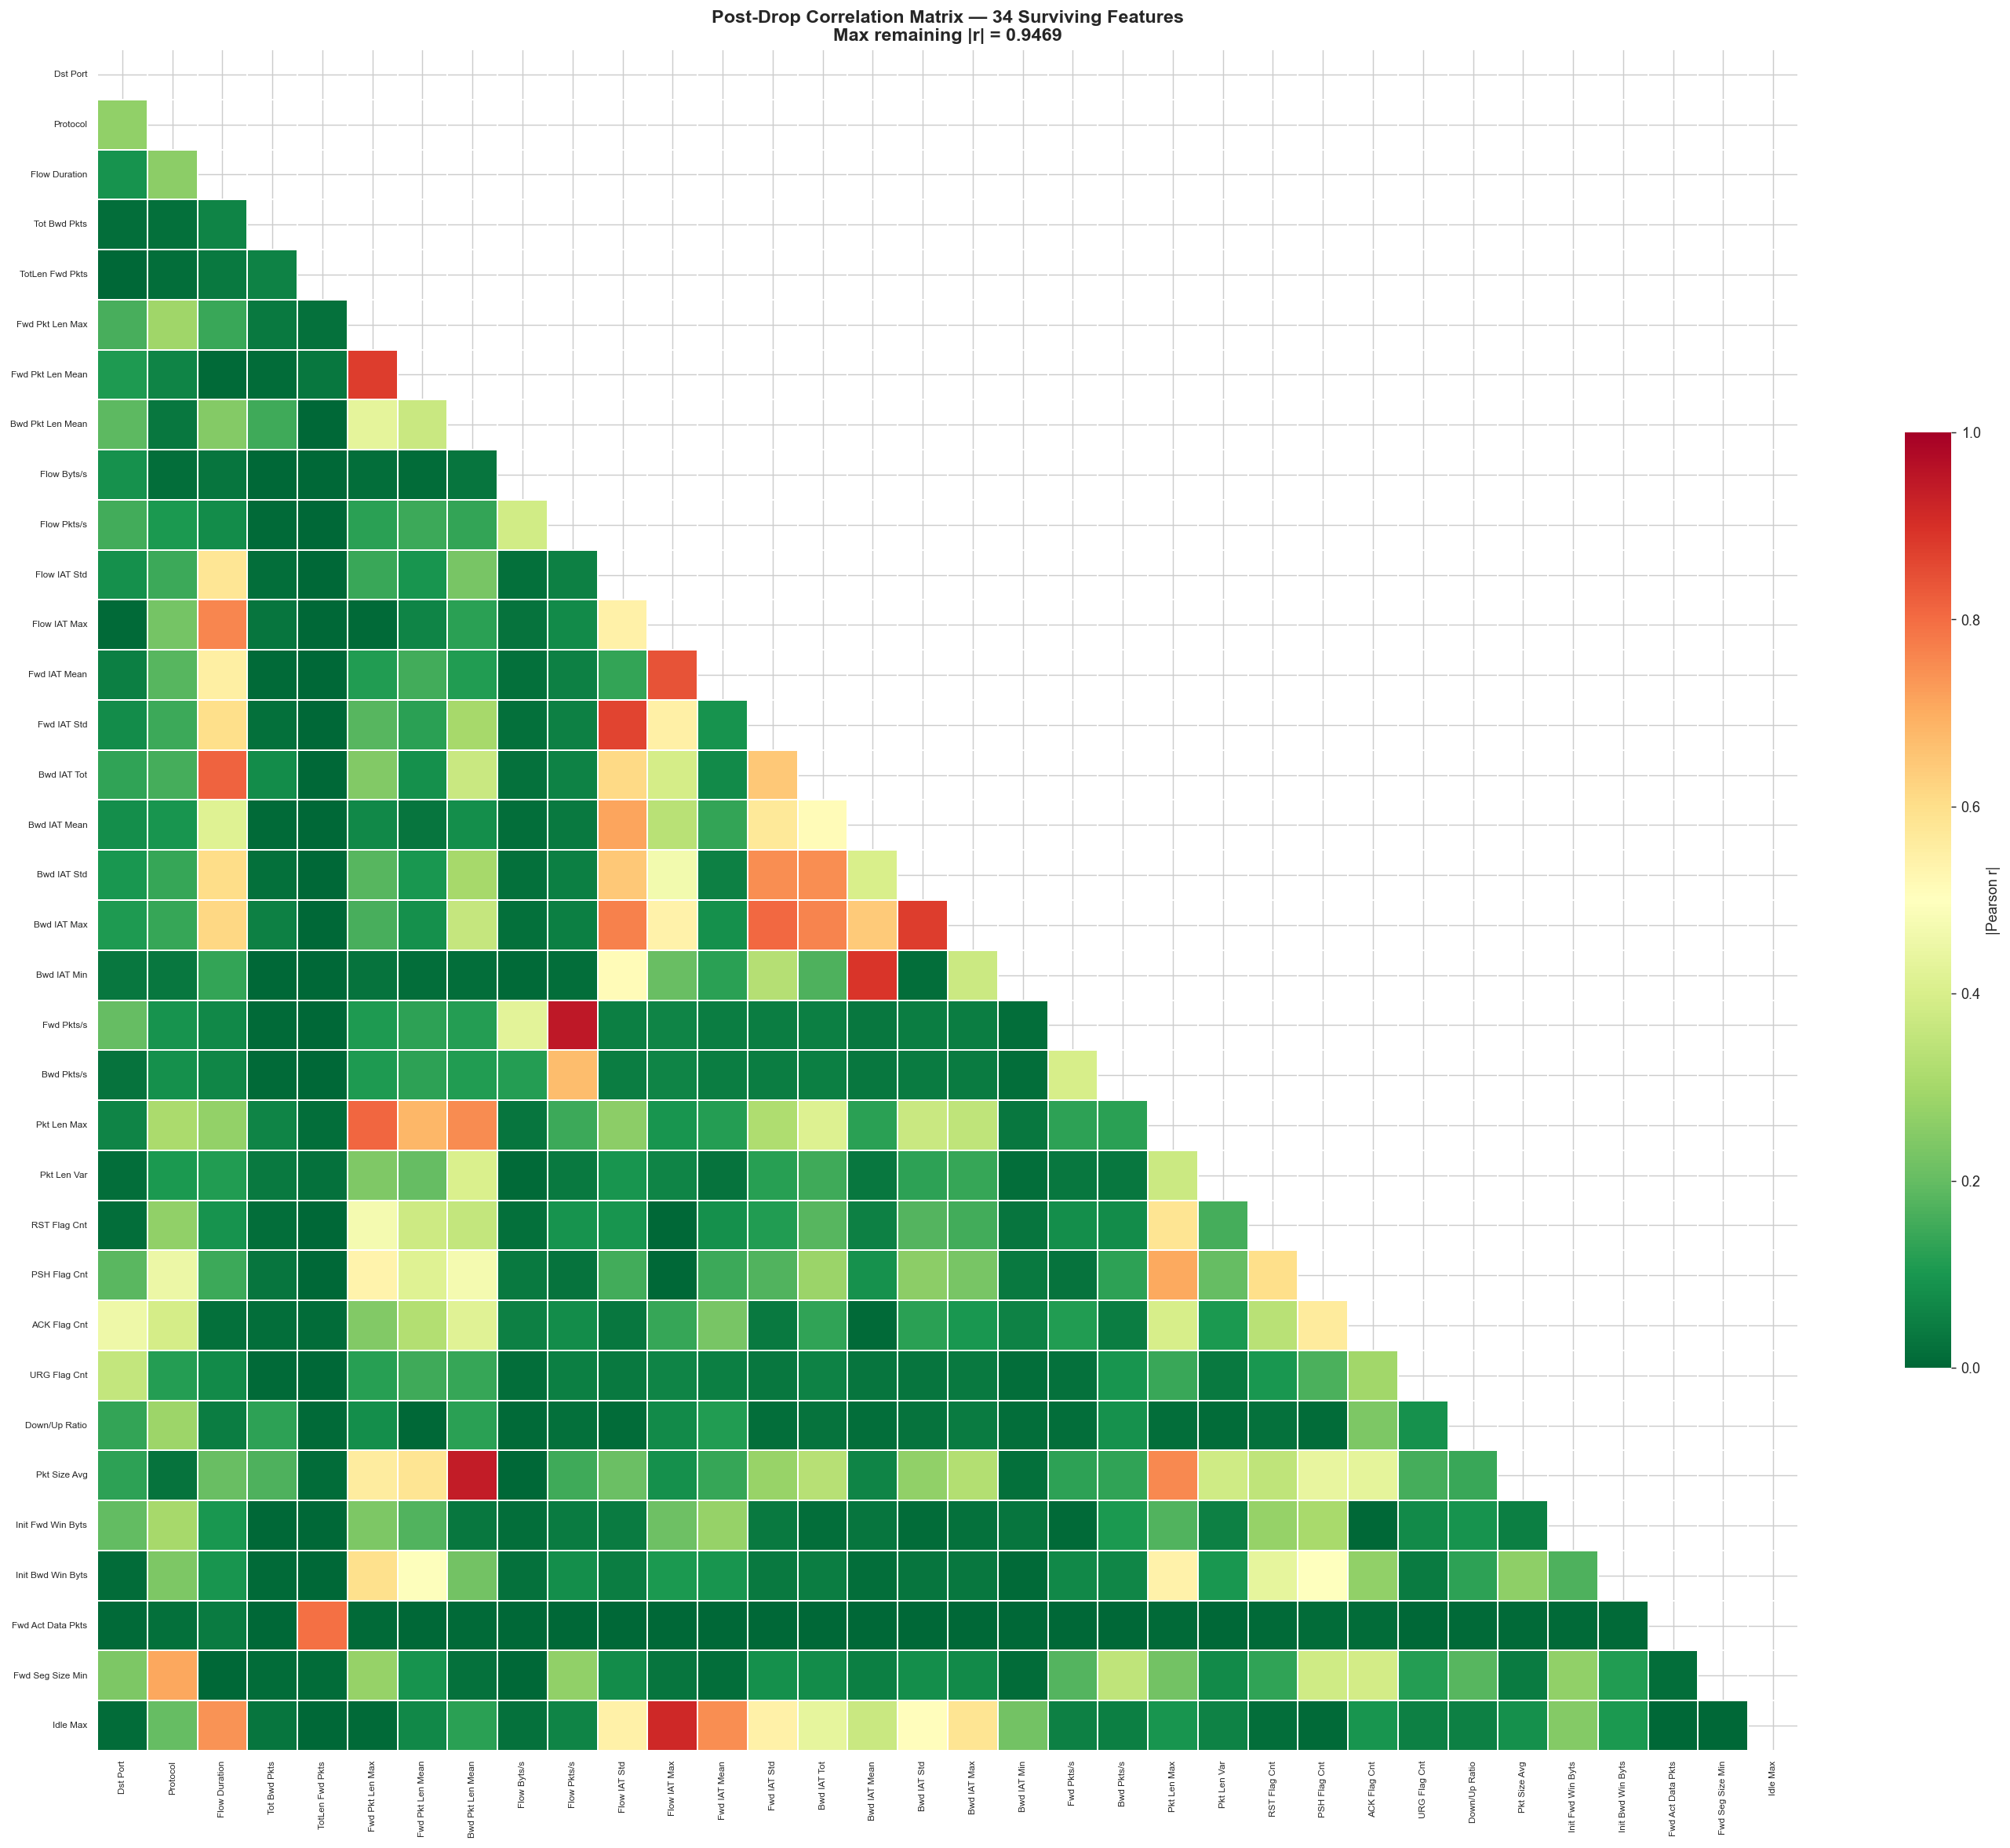

✅ Saved → correlation_analysis/10_post_drop_heatmap.png


In [13]:
print('Post-drop correlation check on surviving features...')

if USE_FULL_DATA:
    post_samp = X_full
    print(f'   Using full dataset: {post_samp.shape}')
else:
    post_samp = X_full.loc[sample_idx]
    print(f'   Using existing sample: {post_samp.shape}')

post_corr  = post_samp.corr(method='pearson').abs()
upper_post = post_corr.where(np.triu(np.ones(post_corr.shape), k=1).astype(bool))

remaining = (
    upper_post.stack()
    .reset_index()
    .rename(columns={'level_0': 'A', 'level_1': 'B', 0: 'r'})
    .query('r >= @CORR_THRESHOLD')
    .sort_values('r', ascending=False)
)

if len(remaining) == 0:
    print(f'\n✅ CLEAN — No pairs remain above |r| = {CORR_THRESHOLD}')
else:
    print(f'\n⚠️  {len(remaining)} pair(s) still above threshold:')
    print(remaining.to_string(index=False))

print(f'\nMax remaining |r| between features: {upper_post.max().max():.4f}')

fig, ax = plt.subplots(figsize=(22, 19))
mask_post = np.triu(np.ones_like(post_corr, dtype=bool))
sns.heatmap(
    post_corr, mask=mask_post, cmap='RdYlGn_r', vmin=0, vmax=1,
    square=True, linewidths=0.15, ax=ax, annot=False,
    cbar_kws={'label': '|Pearson r|', 'shrink': 0.5}
)
ax.set_title(
    f'Post-Drop Correlation Matrix — {X_full.shape[1]} Surviving Features\n'
    f'Max remaining |r| = {upper_post.max().max():.4f}',
    fontsize=13, fontweight='bold'
)
ax.tick_params(axis='x', labelsize=6.5, rotation=90)
ax.tick_params(axis='y', labelsize=6.5)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}10_post_drop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {OUTPUT_DIR}10_post_drop_heatmap.png')


## 14. Final Report

In [14]:
print('\n' + '=' * 70)
print('🎉 CORRELATION ANALYSIS — FINAL REPORT')
print('=' * 70)
print(f'\n   Dataset       : CIC-IDS-2018')
print(f'   Total rows    : {len(y_full):,}')
print(f'   Original feats: {before_n}')
print(f'   Dropped feats : {before_n - X_full.shape[1]}')
print(f'   Surviving     : {X_full.shape[1]}')

if VARIANCE_DROP:
    print(f'\n  Zero-variance drops ({len(VARIANCE_DROP)}):')
    for f in sorted(VARIANCE_DROP):
        print(f'    - {f}')

if len(drop_df) > 0:
    print(f'\n  Correlation drops ({len(to_drop)}):')
    print(f'  {"Dropped":<35} {"Kept":<35} {"pair_r":>6} {"Δlabel_r":>9}')
    print('  ' + '─' * 88)
    for _, r in drop_df.sort_values('pair_r', ascending=False).iterrows():
        print(f'  {r.dropped:<35} {r.kept:<35} {r.pair_r:>6.4f} {r.label_r_diff:>9.6f}')

print(f'\n  Surviving Features ({X_full.shape[1]}):')
for i, f in enumerate(X_full.columns, 1):
    lr = tc_lookup.get(f, 0)
    print(f'    {i:2d}. {f:<35}  label_r={lr:.4f}')

print(f'\n  Output files saved to: {OUTPUT_DIR}')
print('    descriptive_statistics.csv')
print('    feature_label_correlation.csv')
print('    full_correlation_matrix.csv')
print('    high_correlation_pairs.csv')
print('    drop_decisions.csv')
print('    surviving_features.csv')
print('    01_missing_zero_analysis.png')
print('    02_variance_analysis.png')
print('    03_skewness_analysis.png')
print('    04_feature_label_correlation.png')
print('    05_full_correlation_heatmap.png')
print('    06_high_corr_zoomed_heatmap.png')
print('    07_drop_decisions.png')
print('    08_kept_vs_dropped_label_corr.png')
print('    09_pairplot_top8.png')
print('    10_post_drop_heatmap.png')
print('\n✅ X_full and y_full are ready — continue to your training pipeline!')



🎉 CORRELATION ANALYSIS — FINAL REPORT

   Dataset       : CIC-IDS-2018
   Total rows    : 16,232,928
   Original feats: 57
   Dropped feats : 23
   Surviving     : 34

  Correlation drops (23):
  Dropped                             Kept                                pair_r  Δlabel_r
  ────────────────────────────────────────────────────────────────────────────────────────
  Subflow Fwd Pkts                    Tot Fwd Pkts                        1.0000  0.000000
  Fwd Seg Size Avg                    Fwd Pkt Len Mean                    1.0000  0.000000
  Bwd Seg Size Avg                    Bwd Pkt Len Mean                    1.0000  0.000000
  Subflow Fwd Byts                    TotLen Fwd Pkts                     1.0000  0.000000
  Subflow Bwd Pkts                    Tot Bwd Pkts                        1.0000  0.000000
  TotLen Bwd Pkts                     Subflow Bwd Byts                    1.0000  0.000000
  ECE Flag Cnt                        RST Flag Cnt                        1.0